--- 

# <h1 style="text-align: center;">**Signal Processing for Machine Learning - Final Project**</h1>

### <h3 style="text-align: center;">*Francesco Lazzari, 1917922*</h3>

---

## <code style="background:purple;color:white">**Compressive Sensing**</code>

Per il **`Teorema di Nyquist-Shannon`** la ricostruzione di un segnale di banda limitata a $B$ Hz richiede un campionamento a frequenza di almeno $2B$ Hz. Tale vincolo è molto inefficiente nel contesto dei Big Data poiché impone di acquisire e memorizzare un numero enorme di campioni, molti dei quali contengono informazioni ridondanti.

Il **`Compressive Sensing`** aggira questo limite sfruttando la *`sparsità`* di moltissimi segnali reali se opportunamente cambiati di base. Tale caratteristica ci permette di acquisire il segnale con un numero di campioni drasticamente inferiore a quello imposto dal teorema di Nyquist-Shannon, e di ricostruirlo in maniera accurata tramite algoritmi di ottimizzazione convessa.



$\leadsto$ ***Formalizzazione del problema:*** 
Dato un vettore di misure $\mathbf{y}\in\mathbb{R}^{n}$, legato al segnale sparso $\mathbf{x}\in\mathbb{R}^{m}$ da un operatore lineare noto $\mathbf{A}\in\mathbb{R}^{n\times m}$, con *molte meno misure che incognite* ($n\ll m$):
$$\mathbf{y}=\mathbf{A}\mathbf{x}$$

Cerco la soluzione **più sparsa** compatibile con le misure. La sparsità si misura con la pseudo-norma $\ell_0$, che conta le componenti non nulle:
$$\min_{\mathbf{x}}\ \|\mathbf{x}\|_0\quad\text{s.t.}\quad \mathbf{y}=\mathbf{A}\mathbf{x}$$

Questo è il problema ottimale che vorremmo risolvere, ma è **NP-hard**: trovarne la soluzione richiederebbe di esaminare tutte le possibili combinazioni di componenti non nulle, un numero che cresce esponenzialmente con $m$. Dobbiamo quindi rilassare il problema.


<code style="background:darkred;color:white">**N.B.:**</code> Minimizzare l'MSE (Mean Squared Error) tra $\mathbf{y}$ e $\mathbf{A}\mathbf{x}$ non è sufficiente poiché non garantirebbe la sparsità della soluzione.

---

## <code style="background:purple;color:white">**Rilassamento convesso: il LASSO problem**</code>

### <code style="background:royalblue;color:white">**Dalla norma $\ell_0$ alla norma $\ell_1$**</code>

La soluzione è sostituire la $\ell_0$ con la norma $\ell_1$ (la somma dei valori assoluti) e questo problema convesso, sotto opportune condizioni ($\ell_1$-*coherence* e *Restricted Isometry Property*), garantisce di trovare la stessa soluzione sparsa del problema originale.

Il motivo per cui la $\ell_1$ promuove la sparsità è geometrico. Minimizzare una norma sotto un vincolo lineare equivale a trovare il punto di contatto con lo spazio affine dei vincoli. Il grafico della norma $\ell_1$ è un rombo con i **vertici sugli assi** e il primo contatto avviene quasi sempre in un vertice, che corrispondono a soluzioni sparse per definizione. La palla $\ell_2$, al contrario, è una sfera e il contatto è generico che non favorisce gli assi. Invece le pseudo-norme $\ell_p$ con $p<1$ non sono convesse, quindi non garantiscono di trovare il minimo globale. 

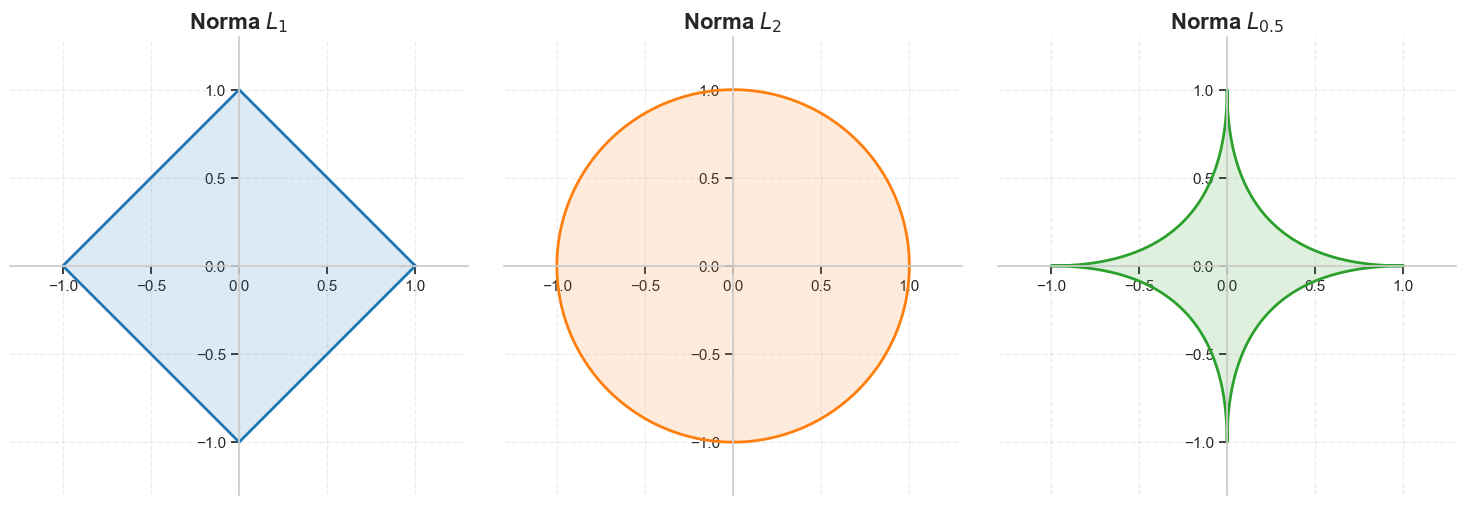

In [ ]:
# ----------------------------------------------------------------------------
# Confronto grafico tra le norme L1, L2 e L0.5 
# ----------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

theta = np.linspace(0, 2 * np.pi, 400)

def lp_ball_boundary(p, theta):
    c, s = np.cos(theta), np.sin(theta)
    x = np.sign(c) * np.abs(c) ** (2.0 / p)
    y = np.sign(s) * np.abs(s) ** (2.0 / p)
    return x, y

norms = {
    r"Norma $L_1$":        (1.0, 'tab:blue'),
    r"Norma $L_2$":      (2.0, 'tab:orange'),
    r"Norma $L_{0.5}$": (0.5, 'tab:green'),
}

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, (p, color)) in zip(axes, norms.items()):
    x_b, y_b = lp_ball_boundary(p, theta)
    ax.plot(x_b, y_b, linewidth=2, color=color)
    ax.fill(x_b, y_b, color=color, alpha=0.15)
    ax.set_title(title, fontsize=16, fontweight='bold')

    # --- piano cartesiano centrato in (0,0) ---
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    lim = 1.3
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal') 

    # frecce alle estremita' degli assi
    #ax.plot(1, 0, ">k", markersize=8, transform=ax.get_yaxis_transform(), clip_on=False)
    #ax.plot(0, 1, "^k", markersize=8, transform=ax.get_xaxis_transform(), clip_on=False)

    ax.grid(True, linestyle='--', color='gray', alpha=0.15)

plt.tight_layout()
plt.show()

### <code style="background:royalblue;color:white">**Basis Pursuit**</code>

A questo punto il problema diventerebbe:
$$\min_{\mathbf{x}}\ \|\mathbf{x}\|_1\quad\text{s.t.}\quad \mathbf{y}=\mathbf{A}\mathbf{x}$$

che è noto come **`Basis Pursuit`** ed è un problema convesso risolvibile in tempo polinomiale. Tuttavia, nella pratica le misure sono affette da rumore, quindi il vincolo esatto $\mathbf{y}=\mathbf{A}\mathbf{x}$ va rilassato in una forma che tollera un piccolo errore di ricostruzione.

### <code style="background:royalblue;color:white">**Formulazione del problema LASSO**</code>

La formulazione del **`LASSO`** problem (`Least Absolute Shrinkage and Selection Operator`) ribalta il problema mettendo la **consistenza con le misure** come funzione obiettivo e la **sparsità** della soluzione (o parsimonia) come vincolo, scrivibile in forma penalizzata tramite moltiplicatore di Lagrange come:

$$\min_{\mathbf{x}\in\mathbb{R}^{m}}\;\underbrace{\frac{1}{2}\|\mathbf{A}\mathbf{x}-\mathbf{y}\|_2^2}_{\text{fedeltà ai dati (smooth)}}\;+\;\underbrace{\lambda\|\mathbf{x}\|_1}_{\text{sparsità (non-smooth)}},\qquad \lambda>0$$

Il parametro $\lambda$ governa il compromesso: un $\lambda$ grande dà più sparsità a scapito della ricostruzione, un $\lambda$ piccolo privilegia il fitting.


<code style="background:darkred;color:white">**N.B.:**</code>

- La matrice $\mathbf{A}$ può rappresentare un operatore fisico di misura (in compressed sensing è fissato dal sistema di acquisizione) oppure un dizionario di atomi su cui rappresentare i dati (in sparse coding è casuale o appreso). In questo progetto $\mathbf{A}$ resta sempre **fisso**, ma la sua scelta dipende dall'esperimento: matrice gaussiana casuale (dati sintetici), dizionario **appreso** dai dati (immagini), oppure DCT più identità $A=(H\mid I)$ (denoising); in tutti i casi con colonne normalizzate a norma unitaria.

- La compressione non viene da una riduzione dimensionale di $\mathbf{x}$ bensì dalla sua **sparsità**, pochi coefficienti non nulli, che permettono di memorizzare o trasmettere solo le coppie (indice, valore) invece dell'intero segnale.

- Anche il Lasso problem è un problema convesso poiché il primo termine è un termine quadratico (quindi convesso) e il secondo termine è una norma (quindi convessa). La loro somma è quindi **convessa**, e questo garantisce che ogni minimo locale sia anche globale.

- Il gradiente della parte liscia, che useremo più avanti è dato da: $\nabla g(\mathbf{x})=\mathbf{A}^\top(\mathbf{A}\mathbf{x}-\mathbf{y}).$

---

## <code style="background:purple;color:white">**ISTA — Iterative Shrinkage-Thresholding Algorithm**</code>

### <code style="background:royalblue;color:white">**Sub-gradient**</code>

L'idea più naturale per minimizzare il LASSO sarebbe la discesa del gradiente. Ma questa richiede che l'obiettivo sia differenziabile ovunque, e la norma $\ell_1$ non lo è in $x_i=0$, infatti la derivata destra vale $+1$ e la sinistra $-1$, quindi il gradiente non esiste. Per gestire questa singolarità si generalizza il concetto di gradiente al **`subgradiente`**, definito componente per componente come

$$[\partial \|x\|_1]_i=\begin{cases}\{+1\} & x_i>0\\[2pt] \{-1\} & x_i<0\\[2pt] [-1,+1] & x_i=0 \end{cases}$$


### <code style="background:royalblue;color:white">**Operatore prossimale e soft-thresholding**</code>

$\leadsto$ ***Definizione:*** Data una funzione convessa $h:\mathbb{R}^N\to\mathbb{R}$ il suo **`operatore prossimale`** è definito come

$$\operatorname{prox}_{h}(\mathbf{v})=\arg\min_{\mathbf{z}}\left\{\frac{1}{2}\|\mathbf{z}-\mathbf{v}\|_2^2+ h(\mathbf{z})\right\}$$

ovvero trova il punto $\mathbf{z}$ che minimizza $h$ restando vicino a $\mathbf{v}$ (intorno quadratico a $\mathbf{v}$). 

Questo è un problema di ottimizzazione convesso, quindi ha soluzione unica ponendo a $0$ il (sub)gradiente dell'obiettivo. Con $h(\mathbf{z})=\lambda\|\mathbf{z}\|_1$ otteniamo:

$$ \mathbf{z}-\mathbf{v}+\lambda\,\text{sign}(\mathbf{z})=0 \quad \Rightarrow \quad \mathbf{z} = \mathbf{v} - \lambda\,\text{sign}(\mathbf{z}) $$

Raccogliendo i tre casi $z_i>0$, $z_i<0$ e $z_i=0$ otteniamo la **`funzione di soft-thresholding`**:
$$ [\mathcal{S}_{\lambda}(\mathbf{v})]_i= \begin{cases} v_i - \lambda & \text{se } v_i > \lambda \\ 0 & \text{se } v_i \in [-\lambda, \lambda] \\ v_i + \lambda & \text{se } v_i < -\lambda \end{cases} $$

$$\Rightarrow \ \mathcal{S}_{\lambda}(\mathbf{v})=\operatorname{sign}(\mathbf{v})\cdot\max(|\mathbf{v}|-\lambda,\,0)$$

<code style="background:darkred;color:white">**N.B.:**</code> 

- Il subgradiente non rende differenziabile la $\ell_1$ (che resta non differenziabile in $x_i=0$), ma generalizza il gradiente per poterla trattare in quel punto.

- La Soft-Thresholding è l'operazione non-lineare che induce sparsità $\to$ ogni componente viene ridotta di $\theta$ in valore assoluto, e tutto ciò che cade sotto soglia viene azzerato. 

### <code style="background:royalblue;color:white">**ISTA Update Rule**</code>

Per una funzione obiettivo composta da una parte liscia $g$ e una parte non liscia $h$, l'algoritmo della **`discesa del gradiente prossimale`** esegue a ogni iterazione un passo di discesa del gradiente su $g$ seguito da un passo prossimale su $h$. Mettendo tutto insieme ottenimo la **`regola di aggiornamento di ISTA`**:


$$\mathbf{x}^{(k+1)} = \operatorname{prox}_{\mu\lambda\| \cdot \|_1}\left(\mathbf{x}^{(k)} - \mu \nabla g(\mathbf{x}^{(k)})\right) = \mathcal{S}_{\lambda\mu}\left(\mathbf{x}^{(k)} - \mu \mathbf{A}^\top(\mathbf{A}\mathbf{x}-\mathbf{y})\right)$$

Possiamo riscrivere la regola di aggiornamento in una forma più compatta, evidenziando la struttura di un layer di rete neurale:

$$\mathbf{x}^{k+1}=\mathcal{S}_{\lambda\mu}\Big(\underbrace{(\mathbf{I}-\mu\,\mathbf{A}^\top\mathbf{A})}_{\text{trasformazione lineare}}\mathbf{x}^{k}+\underbrace{\mu\,\mathbf{A}^\top\mathbf{y}}_{\text{termine sui dati}}\Big)$$

Ogni iterazione è quindi una **trasformazione lineare seguita da una non-linearità**.

<code style="background:darkred;color:white">**N.B.:**</code> 
- ISTA converge all'ottimo del LASSO, ma con un tasso estremamente lento di $O(1/k)$, tipicamente centinaia o migliaia di iterazioni per una buona accuratezza. 

- La convergenza è garantita se il passo di gradiente $\mu$ è scelto pari a $\mu\le 1/L$ dove $L$ è la **costante di Lipschitz** del gradiente della funzione obiettivo, ovvero $||\mathbf{A}^\top\mathbf{A}||_2$.


In [ ]:
# ============================================================================
# librerie, operatore di shrinkage, metriche NMSE e LASSO
# ============================================================================

from dataclasses import dataclass   
from functools import partial       # mi serve per congelare gli argomenti statici nelle funzioni jittate
from typing import Tuple            

import flax.linen as nn             
import jax                          
import jax.numpy as jnp             


# ----------------------------------------------------------------------------
# Operatore di shrinkage (soft-thresholding), cioe' il prox della norma ell-1
# ----------------------------------------------------------------------------

def shrinkage_soft_threshold(x: jnp.ndarray, beta: jnp.ndarray) -> jnp.ndarray:
    # S_beta(x) = sign(x) * max(|x| - beta, 0)
    return jnp.sign(x) * jnp.maximum(jnp.abs(x) - beta, 0.0)


# ----------------------------------------------------------------------------
# Metrica NMSE in dB su un intero dataset/batch
# ----------------------------------------------------------------------------
# NMSE (Normalized Mean Squared Error) = energia dell'errore / energia del target, cosi'
# la metrica non dipende dalla scala del segnale. La esprimo in dB: piu' e' negativa, meglio è

@jax.jit
def nmse_db_from_preds(pred: jnp.ndarray, target: jnp.ndarray, eps: float = 1e-8) -> jnp.ndarray:
    err = jnp.sum((pred - target) ** 2)        # energia dell'errore
    pw = jnp.sum(target ** 2) + eps            # energia del target, con +eps per non dividere per 0
    nmse = err / pw
    return 10.0 * jnp.log10(nmse + 1e-12)      # +1e-12 dentro il log per evitare log10(0)


# ----------------------------------------------------------------------------
# Metrica NMSE in dB a ogni passo t di una sequenza
# ----------------------------------------------------------------------------

@jax.jit
def nmse_db_seq(pred_seq: jnp.ndarray, target: jnp.ndarray, eps: float = 1e-8) -> jnp.ndarray:
    # qui riduco su tutti gli assi tranne lo 0 (l'asse tempo/profondita')
    # sarebbe bastato anche axis=(1,2) ma cosi' e' piu' generale se cambiano le dimensioni di pred_seq
    reduce_axes = tuple(range(1, pred_seq.ndim))
    
    # target[None, ...] aggiunge un asse tempo davanti per il broadcast con pred_seq
    err_t = jnp.sum((pred_seq - target[None, ...]) ** 2, axis=reduce_axes)   
    pw = jnp.sum(target ** 2) + eps                                          
    return 10.0 * jnp.log10(err_t / pw + 1e-12)              

# ----------------------------------------------------------------------------
# Valore della LASSO obj fn lungo la progressione (test di convergenza)
# ----------------------------------------------------------------------------

@jax.jit
def lasso_objective_seq_from_x_seq(
    x_seq: jnp.ndarray,             
    Y: jnp.ndarray,                 
    A: jnp.ndarray,                 
    *,
    lambda_lasso: float,
    ) -> jnp.ndarray:
    # residuo per ogni t e campione: x_seq @ A.T e' (T+1,N,n) = A x^t, poi sottraggo y in broadcast
    resid = x_seq @ A.T - Y[None, ...]
    data_term = 0.5 * jnp.sum(resid**2, axis=(1, 2)) / Y.shape[0]               # media del termine di fedelta'
    l1_term = lambda_lasso * jnp.sum(jnp.abs(x_seq), axis=(1, 2)) / Y.shape[0]  # media della penalita' ell-1
    return data_term + l1_term                                                  # obiettivo LASSO per ogni t               

In [ ]:
# ============================================================================
# ISTA in JAX: solver e obiettivo LASSO (baseline e teacher)
# ============================================================================
# Implemento ISTA in due varianti: 
# - ista_solve      --> ritorna solo x^{n_iters} (non salvo la progressione)
# - ista_solve_all  --> ritorna tutta la sequenza x^0..x^{n_iters} per i plot e la diagnostica. 
# # In piu' valuto l'obiettivo LASSO lungo la traiettoria
# La ricorsione di ISTA e' x^{t+1} = S_{lambda*mu}( x^t - mu (A^T A x^t - A^T y) )


# ----------------------------------------------------------------------------
# Dataclass di iperparametri di ISTA
# ----------------------------------------------------------------------------
# Uso una dataclass per raggruppare gli iperparametri in un solo oggetto (ista_cfg.lambda_lasso, ista_cfg.ista_iters, ...)

@dataclass
class ISTAConfig:
    lambda_lasso: float = 0.1        # regolarizzazione ell-1 (il lambda del LASSO)
    ista_iters: int = 100            # numero di iterazioni di ISTA (profondita' del solver)
    stability_factor: float = 1.001  # tengo mu = 1/(stability_factor*L) strettamente sotto 1/L, per convergenza
    eps: float = 1e-6                # costante anti divisione-per-zero


# ----------------------------------------------------------------------------
# ISTA: solo la stima finale x^{n_iters}
# ----------------------------------------------------------------------------
# Marco n_iters come static_argnames perche' fissa la lunghezza del ciclo cosi' JAX ricompila solo quando cambio n_iters

@partial(jax.jit, static_argnames=('n_iters',))
def ista_solve(
    Y: jnp.ndarray,                
    A: jnp.ndarray,                
    *,                             
    lambda_lasso: float,
    n_iters: int,
    stability_factor: float = 1.001,
    eps: float = 1e-6,
    ) -> jnp.ndarray:

    Y = jnp.asarray(Y)
    A = jnp.asarray(A)

    A_TA = A.T @ A                             
    L = jnp.linalg.norm(A_TA, ord=2)                 # costante di Lipschitz = ||A^T A||_2
    mu = 1.0 / (stability_factor * L + eps)          # passo fisso, appena sotto 1/L
    beta = lambda_lasso * mu                         # soglia del soft-threshold: theta = lambda*mu

    ATy = Y @ A                                      # con Y (N,n) e A (n,m), Y @ A e' (N,m) con riga i = A^T y_i

    x0 = shrinkage_soft_threshold(mu * ATy, beta)    # il primo step partendo da x=0 è x^1 = S(mu A^T y)

    # uso fori_loop(lower, upper, body_fun, init_val) 
    # ovvero, esegue upper-1 volte carry = body_fun(i, carry) per i in range(lower, upper)
    def body_fn(_, x_t):
        W1x = x_t @ A_TA                          
        x_next = shrinkage_soft_threshold(x_t - mu * (W1x - ATy), beta)
        return x_next

    xT = jax.lax.fori_loop(0, n_iters, body_fn, x0)   # eseguo n_iters passi a partire da x0
    return xT


# ----------------------------------------------------------------------------
# ISTA: tutta la progressione x^0..x^{n_iters}
# ----------------------------------------------------------------------------
# Uguale a sopra ma uso jax.lax.scan per accumulare ogni x^t che mi servono per i plot

@partial(jax.jit, static_argnames=('n_iters',))
def ista_solve_all(
    Y: jnp.ndarray,
    A: jnp.ndarray,
    *,
    lambda_lasso: float,
    n_iters: int,
    stability_factor: float = 1.001,
    eps: float = 1e-6,
    ) -> jnp.ndarray:
    Y = jnp.asarray(Y)
    A = jnp.asarray(A)

    A_TA = A.T @ A
    L = jnp.linalg.norm(A_TA, ord=2)
    mu = 1.0 / (stability_factor * L + eps)
    beta = lambda_lasso * mu

    ATy = Y @ A
    x0 = shrinkage_soft_threshold(mu * ATy, beta)

    # Qesta volta uso scan(f, init, xs, length=...) che esegue f(carry, x) per ogni x in xs
    # in scan restituisco x_next sia come carry sia come uscita, cosi' poi le impilo tutte
    def step(x_t, _):
        W1x = x_t @ A_TA
        x_next = shrinkage_soft_threshold(x_t - mu * (W1x - ATy), beta)
        return x_next, x_next

    # xs=None con length=n_iters così lo scan gira a vuoto per n_iters passi (non itero su dati)
    _, x_steps = jax.lax.scan(step, x0, xs=None, length=n_iters)  

    # inserisco un nuovo asse davanti a x0 per avere la sequenza completa x^0..x^{n_iters}
    # perche' x_seq ha shape (n_iters+1, N, m) e x0 aveva solo shape (N, m)
    x_seq = jnp.concatenate([x0[None, ...], x_steps], axis=0)       
    return x_seq

## <code style="background:purple;color:white">**Algorithm unrolling: da ISTA a LISTA**</code>

### <code style="background:royalblue;color:white">**L'idea dell'algorithm unrolling**</code>

Un algoritmo iterativo generico ha la forma $\mathbf{z}^{k+1}=f(\mathbf{z}^{k};\theta^{k})$. L'idea dell'**`algorithm unrolling`** (o unfolding) è di fissare un numero finito $L$ di iterazioni, interpretare ciascuna come un **layer** di una rete, e rendere i parametri $\theta^{\ell}$ **apprendibili** tramite backpropagation, addestrandoli end-to-end su dati. La rete che ne risulta è profonda ma **interpretabile**, perché ogni layer corrisponde a un passo dell'algoritmo di ottimizzazione originale a differenza di una rete generica, che è una scatola nera.

### <code style="background:royalblue;color:white">**Il layer di LISTA**</code>

Applicando questo principio a ISTA si ottiene **`LISTA`** (`Learned ISTA`) il cui layer è definito come:

$$\mathbf{x}^{k+1}=\mathcal{S}_{\beta^k}\big(W_1^k\,\mathbf{x}^k+W_2^k\,\mathbf{y}\big),$$

dove si sono resi apprendibili la matrice  che agisce su $\mathbf{x}^k$, la matrice che agisce su $\mathbf{y}$, e la matrice di parametri $\beta^k$ che controlla la soglia della soft-thresholding. In questo modo LISTA **impara** a fare meglio di ISTA, adattando i pesi e le soglie ai dati.

L'equivalenza con la soluzione di ISTA è data ponendo $W_1 = \mathbf{I}-\mu\mathbf{A}^\top\mathbf{A}$ e $W_2=\mu\mathbf{A}^\top$ e $\beta^k = \lambda\mu$ i quali sono i parametri iniziali di LISTA, che poi vengono ottimizzati durante l'addestramento. 

Nel codice però uso invece una forma **equivalente** ma più vicina alla formulazione di ISTA tenendo il passo $\mu^k$ esplicito e fuori dalle matrici $W_1$ e $W_2$:

$$\boxed{\,x^{k+1}=\mathcal{S}_{\beta^k}\Big(x^k-\mu^k\,(W_1\, x^k - W_2\, y)\Big)\,}$$


I parametri appresi sono $\{W_1,W_2,\beta^k\}$ (ed eventualmente un passo $\mu^k$ esplicito), possono essere condivisi tra i layer (**`tied`**, la forma classica) o distinti per layer (**`untied`**, più espressiva ma con molti più parametri).

### <code style="background:royalblue;color:white">**Vantaggi di LISTA**</code>

L'implementazione di LISTA richiede per costruzione un dataset di training, con coppie $(\mathbf{y},\mathbf{x}^\star)$, così come un tempo di addestramento. Tuttavia, il vero vantaggio di questa architettura emerge nell'ottimizzazione del **`tempo di inferenza`** poiché una volta addestrata, la rete neurale $\hat{\mathbf{x}}=f_\theta(\mathbf{y})$ può ricostruire i codici sparsi in pochi layer fissi, senza dover eseguire l'ottimizzazione iterativa di ISTA che abbiamo già detto convergere molto lentamente. Questo significa che, per nuovi input $\mathbf{y}$, LISTA fornisce una soluzione rapida e accurata, riducendo drasticamente il tempo computazionale rispetto a ISTA.

<code style="background:darkred;color:white">**Problemi:**</code> 

- L'addestramento di LISTA richiede un dataset di training con coppie $(\mathbf{y},\mathbf{x}^\star)$ di cui il segnale sparso vero $\mathbf{x}^\star$ non è sempre disponibile. In questo caso si può usare ISTA a molte iterazioni come **teacher** e addestrare LISTA come **student** a riprodurne l'output. In questo caso però, per costruzione, il meglio che LISTA può fare è *eguagliare* il teacher quando in generale LISTA può anche fare meglio, imparando a compensare la **`distorsione`** del LASSO problem (i.e. il vincolo di sparsità della soluzione).


### <code style="background:royalblue;color:white">**Weight coupling e il teorema di Chen**</code>

In ISTA i pesi non sono liberi: derivano tutti dalla stessa matrice $\mathbf{A}$. Rendendoli apprendibili in LISTA, ci si chiede quanto siano *davvero* liberi. La risposta è data dal seguente teorema.

$\leadsto$ ***Teorema X.Chen et al. 2018 :*** 

Sia $\mathbf{y}=\mathbf{A}\mathbf{x}^\star$ un'osservazione senza rumore, $\mathbf{x}^0=\mathbf{0}$, e $\{\mathbf{x}^t\}$ la sequenza generata da LISTA. Se $\mathbf{x}^t\to\mathbf{x}^\star$ (LISTA converge alla soluzione sparsa vera) e i pesi restano limitati (i.e. non "esplodono"), allora **necessariamente** per $t\to\infty$ le due matrici lineari soddisfano una **relazione di accoppiamento** $W_2^t-(\mathbf{I}-W_1^t\mathbf{A})\to 0$ e le **soglie si annullano** ($\beta^t\to 0$).

$\leadsto$ ***Interpretazione:***

- Affinché LISTA converga al segnale sparso vero $x^\star$, i suoi pesi non possono restare liberi ma devono soddisfare un accoppiamento determinato da $A$ (cioè $W_1=W_2A$) e le soglie devono annullarsi ($\beta^t\to 0$).

- Le soglie di ISTA introducono un bias dovuto alla penalità $\ell_1$ (che restringe i coefficienti non nulli). Annullando queste soglie LISTA rimuove la distorsione arrivando al vero $x^\star$, mentre ISTA resta ferma sulla soluzione distorta del LASSO.

- L'inizializzazione $W_1=\mathbf{A}^\top\mathbf{A}$, $W_2=\mathbf{A}^\top$ soddisfa già quell'accoppiamento e quindi LISTA può partire dalla soluzione di ISTA e poi migliorare la ricostruzione imparando a ridurre le soglie $\beta^t$.


### <code style="background:royalblue;color:white">**Addestramento e Valutazione**</code>

$\leadsto$ ***Loss Function:*** Uso una Mean Squared Error (MSE) tra il segnale sparso vero $\mathbf{x}^\star$ e quello ricostruito $\hat{\mathbf{x}}$ come funzione obiettivo da minimizzare durante l'addestramento:

$$ \mathcal{L}(\hat{\mathbf{x}},\mathbf{x}^\star)=\frac{1}{N}\sum_{i=1}^{N}(\hat{x}_i-x_i^\star)^2$$

$\leadsto$ ***Metrica di valutazione:*** Uso la Normalized Mean Squared Error (NMSE) per valutare le prestazioni del modello, definita come:

$$\mathrm{NMSE}=\frac{\sum\|\hat x-x^\star\|_2^2}{\sum\|x^\star\|_2^2},\qquad \mathrm{NMSE}_{\mathrm{dB}}=10\log_{10}(\mathrm{NMSE})$$

Più è bassa e più la ricostruzione è accurata.

In [ ]:
# ============================================================================
# LISTA come modulo in Flax --> unrolling di ISTA in una rete a L layer
# ============================================================================
# Update di ogni layer t = 1..L:
#     x^{t+1} = S_{beta[t]}( x^t - mu[t] * ( W1 x^t - W2 y ) )

# ----------------------------------------------------------------------------
# Inversa stabile della softplus
# ----------------------------------------------------------------------------
# La uso per l'inizializzazione di mu e beta 
# durante l'addestramento voglio che mu e beta siano strettamente positivi, quindi li passo attraverso la softplus
# quindi per avere mu e beta iniziali pari al vero valore in input devo prima invertirli

def softplus_inverse(y: jnp.ndarray, eps: float = 1e-8) -> jnp.ndarray:
    """Inversa stabile della softplus: softplus^{-1}(y) = log(expm1(y))."""
    return jnp.log(jnp.expm1(jnp.maximum(y, eps)))

# ----------------------------------------------------------------------------
# Il modulo LISTA
# ----------------------------------------------------------------------------

class LISTAFlaxV2(nn.Module):
    A: jnp.ndarray                       # dizionario A che serve solo per l'inizializzazione dei pesi
    n_layers: int = 16                   # numero di iterazioni di ISTA da imparare in LISTA
    tied_weights: bool = True            # True: W1,W2 condivisi da tutti i layer (classico); False: uno stack per layer
    beta0: float = 0.4                   # sarebbe lambda ma non posso usare quel nome perche' e' una parola riservata
    stability_factor: float = 1.001      # tiene mu_init strettamente sotto 1/L, per la convergenza del proximal gradient
    eps: float = 1e-6                    # anti /0 e offset per tenere mu,beta strettamente positivi

    # setup() gira sia in .init() (per creare i parametri) sia in .apply() (per leggerli)
    def setup(self):
        # 1) prendo le dimensioni dal dizionario A (dim_y, dim_x)
        A = jnp.asarray(self.A)
        self.dim_y = int(A.shape[0])   
        self.dim_x = int(A.shape[1])   

        # 2) init ISTA-like: norm = stability_factor * ||A^T A||_2 (cioe' 1.001*L)
        A_TA = A.T @ A
        L = self.stability_factor * jnp.linalg.norm(A_TA, ord=2)
        mu_init = 1.0 / (L + self.eps)            # passo iniziale  1/L come ISTA
        beta_init = self.beta0 / (L + self.eps)   # calcolo beta_init = lambda * mu_init, con lambda = beta0 

        # 3) ho un vettore mu[t], beta[t] per t = 0..n_layers (un valore per layer, e' parte della capacita' extra su ISTA)
        # durante l'addestramento applico softplus + eps per tenere mu, beta strettamente positivi
        # tuttavia, per fare in modo che il primo step usi i parametri che passo come mu_init e beta_init
        # devo partire dalla loro inversa softplus, cosi' che softplus(raw_init) valga il valore iniziale voluto
        mu_raw_init = softplus_inverse(jnp.full((self.n_layers + 1,), mu_init))
        beta_raw_init = softplus_inverse(jnp.full((self.n_layers + 1,), beta_init))
        
        # self.param(nome, init_fn, shape) registra un parametro addestrabile 
        # la init_fn ha firma (key, *args) ma qui ignoro la key, perche' voglio un'inizializzazione non casuale
        self.mu_raw = self.param('mu_raw', lambda key, shape: mu_raw_init, (self.n_layers + 1,))
        self.beta_raw = self.param('beta_raw', lambda key, shape: beta_raw_init, (self.n_layers + 1,))

        # 4) inizializzo W2 = A^T (m,n) e W1 = A^T A (m,m) quindi parto dai parametri ISTA 
        W2_init = A.T
        W1_init = A_TA

        if self.tied_weights:
            # pesi condivisi tra tutti i layer
            self.W2 = self.param('W2', lambda key, shape: W2_init, (self.dim_x, self.dim_y))
            self.W1 = self.param('W1', lambda key, shape: W1_init, (self.dim_x, self.dim_x))
        else:
            # i pesi sono distinti per layer 
            # replico l'init su un nuovo asse ottenendo uno stack (n_layers +1, m, n) e (n_layers+1, m, m)
            W2_stack_init = jnp.broadcast_to(W2_init, (self.n_layers + 1, self.dim_x, self.dim_y))
            W1_stack_init = jnp.broadcast_to(W1_init, (self.n_layers + 1, self.dim_x, self.dim_x))
            
            self.W2_stack = self.param('W2_stack', lambda key, shape: W2_stack_init, (self.n_layers + 1, self.dim_x, self.dim_y))
            self.W1_stack = self.param('W1_stack', lambda key, shape: W1_stack_init, (self.n_layers + 1, self.dim_x, self.dim_x))

    # impongo che mu e beta siano strettamente positivi tramite softplus + eps 
    def _get_mu_beta(self) -> Tuple[jnp.ndarray, jnp.ndarray]:
        mu = nn.softplus(self.mu_raw) + self.eps
        beta = nn.softplus(self.beta_raw) + self.eps
        return mu, beta

    # __call__ e' il forward di default (model.apply(params, y))
    # ritorna solo la stima finale x^n_layers e non tutta la sequenza x^0..x^n_layers
    def __call__(self, y: jnp.ndarray) -> jnp.ndarray:
        xL, _ = self.forward_all(y)
        return xL

    # mi serve per la curva NMSE-per-layer
    def forward_all(self, y: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
        """
        Ritorna:
          - xL    : stima finale dopo n_layers layer, shape (N, m)
          - x_seq : tutte le stime intermedie x^0..x^{n_layers}, shape (n_layers+1, N, m)
        """
        y = jnp.asarray(y)
        mu, beta = self._get_mu_beta()   

        # ------------------------- caso TIED -------------------------
        if self.tied_weights:
            # Lo calcolo una volta sola perche' e' costante rispetto a x_t
            W2y = y @ self.W2.T

            # layer 0 --> primo step partendo da x=0 --> x^0 = S_{beta0}( mu0 * A^T y )
            x0 = shrinkage_soft_threshold(mu[0] * W2y, beta[0])

            # il carry dello scan e' x_t
            # t_idx serve solo a leggere mu/beta del layer
            def step(x_t, t_idx):
                W1x = x_t @ self.W1.T                 
                x_next = shrinkage_soft_threshold(
                    x_t - mu[t_idx] * (W1x - W2y),    # passo al proximal-gradient con mu,beta del layer
                    beta[t_idx],
                )
                return x_next, x_next          

            # stessa logica dello scan di ista_solve_all
            # itero su t_idx = 1..n_layers, accumulo x_t e restituisco x^L
            t_idxs = jnp.arange(1, self.n_layers + 1)
            xL, x_steps = jax.lax.scan(step, x0, t_idxs)           
            x_seq = jnp.concatenate([x0[None, ...], x_steps], axis=0) 
            return xL, x_seq

        # ------------------------ caso UNTIED ------------------------
        else:
            # qui ogni layer ha i suoi W1_t, W2_t (oltre che a mu_t, beta_t)
            W2y0 = y @ self.W2_stack[0].T                 # A^T y col W2 del layer 0
            x0 = shrinkage_soft_threshold(mu[0] * W2y0, beta[0])

            # slice per i layer 1..L, allineati sullo stesso asse-layer di lunghezza L
            W1_seq = self.W1_stack[1:self.n_layers + 1]   # (L, m, m)
            W2_seq = self.W2_stack[1:self.n_layers + 1]   # (L, m, n)
            mu_seq = mu[1:self.n_layers + 1]              # (L,)
            beta_seq = beta[1:self.n_layers + 1]          # (L,)

            def step(x_t, inputs):
                W1_t, W2_t, mu_t, beta_t = inputs         # parametri del layer corrente
                W2y_t = y @ W2_t.T                        
                W1x_t = x_t @ W1_t.T                       
                x_next = shrinkage_soft_threshold(x_t - mu_t * (W1x_t - W2y_t), beta_t)
                return x_next, x_next

            # lo scan itera in parallelo su tutti gli xs = (W1_seq, W2_seq, mu_seq, beta_seq) e a ogni passo spacchetta gli inputs
            xL, x_steps = jax.lax.scan(step, x0, (W1_seq, W2_seq, mu_seq, beta_seq))
            x_seq = jnp.concatenate([x0[None, ...], x_steps], axis=0)
            return xL, x_seq

In [ ]:
# ============================================================================
# Training step jittato e loop riutilizzabile 
# ============================================================================
import numpy as np                          # faccio il batching su CPU in numpy, per non far ricompilare JAX
import optax                                # ottimizzatori per JAX (qui Adam)
from flax.training import train_state       # contenitore comodo: params + optimizer + apply_fn


# ----------------------------------------------------------------------------
# 1) Mini-batching in numpy (shuffle + drop_last)
# ----------------------------------------------------------------------------
# Lo faccio in numpy per avere batch di dimensione fissa: permuto gli indici a ogni epoca
# e scarto la coda che non riempie un batch intero (drop_last), cosi' ogni batch ha
# esattamente batch_size righe e JAX compila train_step una volta sola (niente ricompilazioni
# per un ultimo batch piu' corto)

def iterate_minibatches_np(
    rng: np.random.Generator,
    Y: np.ndarray,
    X: np.ndarray,
    batch_size: int,
    ):
    """Generatore di mini-batch (shuffle + drop_last)."""
    n = Y.shape[0]
    perm = rng.permutation(n)                       # ordine casuale degli indici
    n_drop = (n // batch_size) * batch_size         # numero di campioni divisibile per batch_size
    perm = perm[:n_drop]                            # scarto la coda incompleta
    for i in range(0, n_drop, batch_size):
        idx = perm[i:i + batch_size]
        yield Y[idx], X[idx]                        # restituisco un batch (Y_b, X_b)


# ----------------------------------------------------------------------------
# 2) Un singolo passo di training (jittato)
# ----------------------------------------------------------------------------
# - state contiene params e optimizer
# - state.apply_fn e' il forward (model.apply) 
# - loss_fn dipende solo da params, cosi' il gradiente e' rispetto a params 
# - value_and_grad mi da' loss e gradiente in un colpo solo
# - apply_gradients fa l'update Optax e torna un nuovo state (in JAX lo stato e' immutabile)

@jax.jit
def train_step_mse(state: train_state.TrainState, y_batch: jnp.ndarray, x_batch: jnp.ndarray):

    def loss_fn(params):
        x_hat = state.apply_fn(params, y_batch)    # forward LISTA: predice i segnali sparsi dal batch y
        return jnp.mean((x_hat - x_batch) ** 2)    # MSE media (student vs target)

    loss, grads = jax.value_and_grad(loss_fn)(state.params) 
    state = state.apply_gradients(grads=grads)               # update Adam -> nuovo state
    return state, loss


# ----------------------------------------------------------------------------
# 3) Valutazione su un intero dataset (MSE e NMSE in dB)
# ----------------------------------------------------------------------------
@jax.jit
def eval_mse_nmse_db(state: train_state.TrainState, Y: jnp.ndarray, X: jnp.ndarray):
    """Ritorna (MSE, NMSE_dB) calcolate sull'intero dataset passato."""
    x_hat = state.apply_fn(state.params, Y)
    mse = jnp.mean((x_hat - X) ** 2)
    nmse_db = nmse_db_from_preds(x_hat, X)        
    return mse, nmse_db


# ----------------------------------------------------------------------------
# 4) Loop di training completo 
# ----------------------------------------------------------------------------
def train_supervised_loop(
    *,
    state: train_state.TrainState,
    Y_train_np: np.ndarray,
    X_train_np: np.ndarray,
    Y_test_np: np.ndarray,
    X_test_np: np.ndarray,
    batch_size: int,
    n_epochs: int,
    seed: int = 0,
    verbose_every: int = 5,
    ):
    """
    Alleno LISTA minimizzando MSE(x_hat, x_target) sui mini-batch, e loggo MSE/NMSE(dB) su train e test (valutati sull'intero dataset a fine epoca)
    
    Restituisco (state, history)
    """
    Y_train = jnp.asarray(Y_train_np)
    X_train = jnp.asarray(X_train_np)
    Y_test = jnp.asarray(Y_test_np)
    X_test = jnp.asarray(X_test_np)

    history = {                                     # storico delle metriche per i plot
        'train_loss': [], 'train_mse': [], 'test_mse': [],
        'train_nmse_db': [], 'test_nmse_db': [],
    }

    rng_np = np.random.default_rng(seed)           # RNG numpy per lo shuffle dei batch
    for epoch in range(1, n_epochs + 1):
        running_loss = 0.0
        n_batches = 0

        # fase di training: un update per mini-batch
        for y_b_np, x_b_np in iterate_minibatches_np(rng_np, Y_train_np, X_train_np, batch_size):
            y_b = jnp.asarray(y_b_np)              # converto il singolo batch in jnp
            x_b = jnp.asarray(x_b_np)
            state, loss = train_step_mse(state, y_b, x_b)
            running_loss += float(loss)
            n_batches += 1

        # fase di valutazione: metriche sull'intero train e test
        train_mse, train_nmse = eval_mse_nmse_db(state, Y_train, X_train)
        test_mse, test_nmse = eval_mse_nmse_db(state, Y_test, X_test)

        history['train_loss'].append(running_loss / max(n_batches, 1))  # loss media sui batch
        history['train_mse'].append(float(train_mse))
        history['test_mse'].append(float(test_mse))
        history['train_nmse_db'].append(float(train_nmse))
        history['test_nmse_db'].append(float(test_nmse))

        if epoch == 1 or epoch % verbose_every == 0:
            print(
                f"Epoch {epoch:02d} | "
                f"loss(batch)={history['train_loss'][-1]:.6f} | "
                f"MSE train={history['train_mse'][-1]:.3e} test={history['test_mse'][-1]:.3e} | "
                f"NMSE train={history['train_nmse_db'][-1]:.2f} dB test={history['test_nmse_db'][-1]:.2f} dB"
            )

    return state, history

## <code style="background:purple;color:white">**Esperimento 1 — Test su dati sintetici**</code>

Prima di usare dati reali (dove non ho le vere stime sparse) faccio un test su dei dati sintetici che genero io stesso $(x^\star, y)$ con un modello noto, così posso verificare che:
1. la rete LISTA si addestri correttamente (la NMSE scende epoca dopo epoca);
2. valga il risultato teorico atteso, cioè che **LISTA ottenga una soluzione più sparsa di ISTA a parità di profondità**

$\leadsto$ ***Generazione dei dati (funzione `make_synthetic_sparse_dataset`):***
- **$x^\star$ sparso** tramite maschera Bernoulliana ($p$) in cui assegno valori casuali da una distribuzione normale $\mathcal{N}(0,1)$;

- **osservazioni** $y$ applicando la relazione $y = x^\star A^\top$ a cui aggiungo un rumore gaussiano calibrato su un **SNR** (Signal-to-Noise Ratio) fissato, con $\sigma^2_{\text{noise}} = \text{Power}_{\text{noise}} =\text{Power}_{\text{signal}}/\text{SNR}$.

- **Setup numerico:** $n=250$ misure, $m=500$ atomi ($m>n$, sotto-determinato), sparsità $p=0.1$, SNR alto ($10^4$, quasi noiseless), $L=16$ layer. La matrice $A$ è gaussiana con *colonne normalizzate*.

<code style="background:darkred;color:white">**N.B.:**</code> 

- Il SNR (Signal-to-Noise Ratio) è un parametro che misura la quantità di rumore presente nel segnale rispetto al segnale stesso. Un SNR alto indica che il segnale è molto più forte del rumore, mentre un SNR basso indica che il rumore è significativo rispetto al segnale. 

- Il PSNR (Peak Signal-to-Noise Ratio) è una misura simile al SNR, ma si concentra sul rapporto tra il massimo valore dei pixel dell'immagine e il rumore tra le due immagini. Questo è particolarmente utile per valutare la qualità della ricostruzione di immagini, poiché tiene conto della scala dei valori dei pixel. La formula per calcolare il PSNR è la seguente:

$$\text{PSNR}=10\log_{10}\frac{\max(I)^2}{\text{MSE }(\hat{y}, y)} $$



In [6]:
# ============================================================================
# Esperimento 1: dati sintetici, setup e training di LISTA
# ============================================================================


# ----------------------------------------------------------------------------
# Generatore di dati sparsi sintetici
# ----------------------------------------------------------------------------
# Genero (X_true, Y) da un modello noto, cosi' il target del training e' il codice vero:
# X_true e' sparso (maschera Bernoulli(p) per ampiezze gaussiane), Y = A X_true + rumore
# con rumore calibrato su un SNR (Signal-to-Noise Ratio) fissato

def make_synthetic_sparse_dataset(
    rng: jax.random.PRNGKey,
    A: jnp.ndarray,
    n_samples: int,
    p: float = 0.1,                 # probabilita' che una componente sia attiva (sparsita')
    snr: float = 1e4,               # rapporto segnale/rumore (alto = quasi noiseless)
    ) -> tuple[jnp.ndarray, jnp.ndarray]:
    A = jnp.asarray(A)
    n_meas, n_atoms = A.shape

    # in JAX la casualita' e' esplicita: da una chiave derivo sotto-chiavi indipendenti con split
    rng, rng_mask, rng_peaks, rng_noise = jax.random.split(rng, 4)

    mask = jax.random.bernoulli(rng_mask, p=p, shape=(n_samples, n_atoms))   # (N,m) booleana
    peaks = jax.random.normal(rng_peaks, shape=(n_samples, n_atoms))         # (N,m) ampiezze ~ N(0,1)
    X_true = peaks * mask.astype(peaks.dtype)                                # azzero le componenti non attive

    Y = X_true @ A.T                # (N,m)@(m,n) = (N,n) con riga i = A x_i 

    # rumore gaussiano con varianza scelta per ottenere lo SNR voluto
    signal_power = jnp.mean(Y ** 2)
    noise_var = signal_power / snr
    noise = jax.random.normal(rng_noise, shape=Y.shape) * jnp.sqrt(noise_var + 1e-12)
    Y = Y + noise

    return Y.astype(jnp.float32), X_true.astype(jnp.float32)


# ----------------------------------------------------------------------------
# Iperparametri del test sintetico
# ----------------------------------------------------------------------------
n_layers = 16        # profondita' di LISTA (e n. iterazioni ISTA nel confronto)
n_atoms = 500        # m: dimensione del codice x
n_meas = 250         # n: dimensione dell'osservazione y (m > n, quindi sotto-determinato)
p = 0.1              # sparsita' attesa 
snr = 1e4            # SNR alto: regime quasi noiseless

n_train = 10000      # campioni di training
n_test = 1000        # campioni di test
batch_size = 512
lr = 5e-3            # learning rate di Adam
n_epochs = 20

# chiave casuale iniziale: da qui derivo tutte le altre con split, per riproducibilita'
rng = jax.random.PRNGKey(4321)

# A dizionario gaussiano con varianza 1/n_meas, poi normalizzo le colonne
rng, rng_A = jax.random.split(rng)
A = jax.random.normal(rng_A, shape=(n_meas, n_atoms)) * jnp.sqrt(1.0 / n_meas)
A = A / (jnp.linalg.norm(A, axis=0, keepdims=True) + 1e-12)

# dataset di train e test con chiavi distinte, cosi' non si sovrappongono
rng, rng_tr, rng_te = jax.random.split(rng, 3)
Y_train, X_train = make_synthetic_sparse_dataset(rng_tr, A, n_train, p=p, snr=snr)
Y_test, X_test = make_synthetic_sparse_dataset(rng_te, A, n_test, p=p, snr=snr)

# copio in numpy per il batching (iterate_minibatches_np lavora su numpy)
Y_train_np = np.array(Y_train)
X_train_np = np.array(X_train)
Y_test_np = np.array(Y_test)
X_test_np = np.array(X_test)

# ----------------------------------------------------------------------------
# Modello, inizializzazione, TrainState
# ----------------------------------------------------------------------------
model = LISTAFlaxV2(
    A=A,
    n_layers=n_layers,
    tied_weights=True,             # pesi condivisi (warm start = ISTA)
    beta0=0.4,                     
    )

# model.init(key, input_di_esempio) esegue setup() e crea i params
# l'input serve per ottenere le shape (uso una riga Y_train_np[:1]) ma i suoi valori non contano
rng, rng_init = jax.random.split(rng)
params = model.init(rng_init, jnp.asarray(Y_train_np[:1]))

# stampa una tabella riassuntiva di layer, shape e numero di parametri
print(model.tabulate(jax.random.PRNGKey(0), jnp.asarray(Y_train_np[:1])))

state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=params,
    # metto il gradient clipping (global-norm) prima di Adam per stabilizzare il training
    tx=optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr)),
    )

# ----------------------------------------------------------------------------
# Training (riuso il loop generico definito prima)
# ----------------------------------------------------------------------------
state, history = train_supervised_loop(
    state=state,
    Y_train_np=Y_train_np, X_train_np=X_train_np,
    Y_test_np=Y_test_np, X_test_np=X_test_np,
    batch_size=batch_size,
    n_epochs=n_epochs,
    seed=0,
    verbose_every=5,
    )

# ----------------------------------------------------------------------------
# Test: NMSE per layer (quanto migliora la stima con la profondita')
# ----------------------------------------------------------------------------
@jax.jit
def eval_nmse_per_layer_db(params, Y: jnp.ndarray, X: jnp.ndarray) -> jnp.ndarray:
    _, x_seq = model.apply(params, Y, method=LISTAFlaxV2.forward_all)
    return nmse_db_seq(x_seq, X)

nmse_per_layer_db = eval_nmse_per_layer_db(state.params, Y_test, X_test)
# print('NMSE LISTA per layer (test):', np.array(nmse_per_layer_db)[:5])  # stampo solo i primi 5 layer per non intasare la console


                              LISTAFlaxV2 Summary                               
┏━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path ┃ module      ┃ inputs         ┃ outputs        ┃ params                ┃
┡━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│      │ LISTAFlaxV2 │ float32[1,250] │ float32[1,500] │ W1: float32[500,500]  │
│      │             │                │                │ W2: float32[500,250]  │
│      │             │                │                │ beta_raw: float32[17] │
│      │             │                │                │ mu_raw: float32[17]   │
│      │             │                │                │                       │
│      │             │                │                │ 375,034 (1.5 MB)      │
├──────┼─────────────┼────────────────┼────────────────┼───────────────────────┤
│      │             │                │          Total │ 375,034 (1.5 MB)      │
└──────┴─────────────┴─────

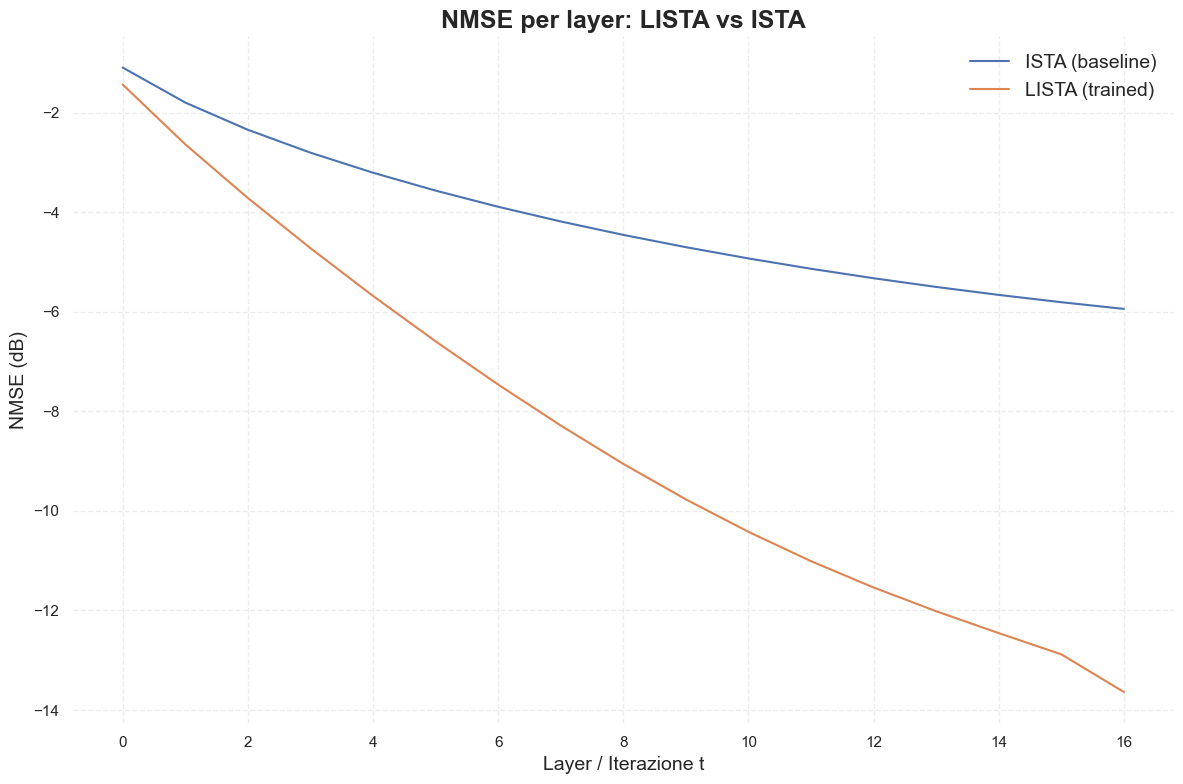

In [7]:
# ============================================================================
# Plot: LISTA vs ISTA, NMSE(dB) per layer/iterazione (dati sintetici)
# ============================================================================
# Confronto, a parita' di profondita' t, la NMSE rispetto al codice vero x* di ISTA e LISTA 

import matplotlib.pyplot as plt
import seaborn as sns

# baseline ISTA sulla stessa A e sullo stesso test set 
# Scelgo lambda_lasso = beta0 (0.4) cosi' la soglia di ISTA (beta = lambda*mu) coincide col beta_init di LISTA
# quindi all'inizio le due curve partono insieme
x_seq_ista = ista_solve_all(
    Y_test, A,
    lambda_lasso=0.4,
    n_iters=n_layers,                 # stesso numero di passi della profondita' di LISTA
    stability_factor=1.001,
    eps=1e-6,
    )

# NMSE in dB di ISTA a ogni iterazione, rispetto al codice vero X_test
nmse_ista_db = nmse_db_seq(x_seq_ista, X_test)

sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

layers = jnp.arange(0, n_layers + 1)                       
sns.lineplot(x=layers, y=nmse_ista_db, label="ISTA (baseline)")
sns.lineplot(x=layers, y=nmse_per_layer_db, label="LISTA (trained)")  

plt.title("NMSE per layer: LISTA vs ISTA", fontsize=18, fontweight='bold')
plt.xlabel("Layer / Iterazione t", fontsize=14)
plt.ylabel("NMSE (dB)", fontsize=14)
plt.grid(True, linestyle='--', color='gray', alpha=0.15)
plt.legend(prop={'size': 14}, edgecolor='white', facecolor='white', framealpha=0)
sns.despine(left=True, bottom=True)                        # tolgo i bordi del riquadro
plt.tight_layout()
plt.show()

# quello che mi aspetto: la curva LISTA sta sotto quella di ISTA, cioe' a parita' di profondita'
# LISTA stima meglio il codice vero (accelerazione piu' compensazione del bias del LASSO)

### <code style="background:green;color:white">**Interpretazione del risultato del test sintetico**</code>

Il plot precedente confronta, **a parità di profondità** $t$, la NMSE in dB rispetto al codice vero $x^\star$ di:
- **ISTA** ($t$- iterazioni, passo fisso, soglia fissa $\lambda\mu$),
- **LISTA** (risultato del layer $t$, con parametri appresi).

Emergono due fatti:
1. **LISTA scende molto più rapidamente**: con pochi layer raggiunge una NMSE che ISTA otterrebbe solo dopo molte più iterazioni. È l'**accelerazione** che ci aspettavamo.
2. **LISTA arriva più in basso di ISTA**: ISTA è ancorato alla soluzione *biased* del LASSO (la soglia $\lambda\mu$ restringe le ampiezze), mentre LISTA, se addestrata sul codice sparso **vero**, impara a **compensare il bias** e raggiunge una NMSE inferiore.

---

### <code style="background:royalblue;color:white">**Estensione: pesi untied**</code>

Finora ho usato **`pesi tied`** (condivisi tra i layer), la forma classica. Qui provo la variante **`untied`** (un $W_1,W_2$ distinto per ogni layer) sullo *stesso* dataset sintetico: così ho la ground-truth $x^\star$ per i confronti.

$\leadsto$ ***Cosa cambia:***

- **Capacità** $\to$ Untied ha molti più gradi di libertà: ogni layer può implementare una trasformazione diversa. In teoria può raggiungere un errore più basso a parità di profondità.

- **Parametri** $\to$ Il costo è circa $(L{+}1)\times$ i pesi lineari, quindi **molto più parametri** da addestrare (e più memoria per il modello).

- **Rischio** $\to$ Più parametri significa **rischio di overfitting** (gap train/test più ampio) e addestramento più lento.

Parametri  tied :   375,034
Parametri untied: 6,375,034  (x17.0 rispetto a tied)
Epoch 01 | loss(batch)=0.019237 | MSE train=9.274e-03 test=1.388e-02 | NMSE train=-10.32 dB test=-8.59 dB
Epoch 05 | loss(batch)=0.003708 | MSE train=2.955e-03 test=8.569e-03 | NMSE train=-15.29 dB test=-10.69 dB
Epoch 10 | loss(batch)=0.003266 | MSE train=2.831e-03 test=7.889e-03 | NMSE train=-15.48 dB test=-11.05 dB
Epoch 15 | loss(batch)=0.887112 | MSE train=7.529e-02 test=3.228e-02 | NMSE train=-1.23 dB test=-4.93 dB
Epoch 20 | loss(batch)=0.021129 | MSE train=2.172e-02 test=1.876e-02 | NMSE train=-6.63 dB test=-7.28 dB


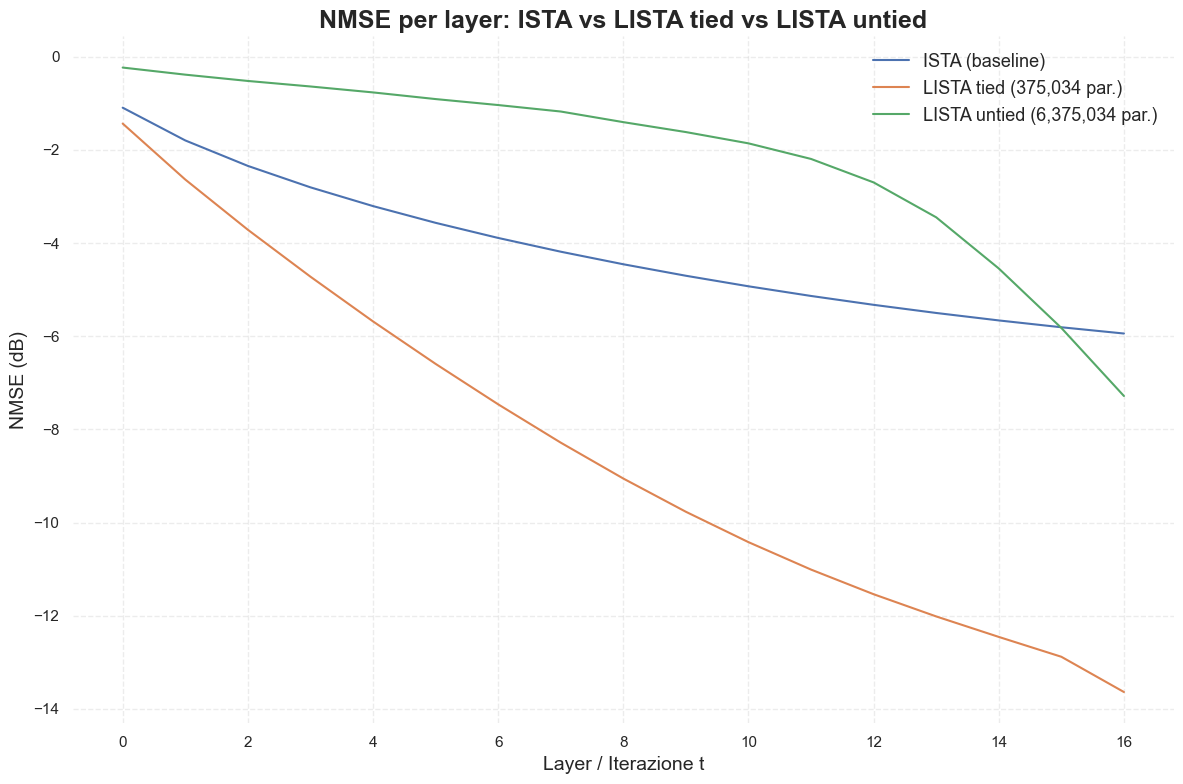

NMSE finale (test)  tied : -13.64 dB
NMSE finale (test) untied: -7.28 dB
Guadagno untied vs tied  : 6.35 dB (se negativo => untied migliore), al costo di 17x parametri


In [8]:
# ============================================================================
# Estensione: LISTA con pesi untied (confronto tied vs untied vs ISTA)
# ============================================================================
# Alleno una seconda LISTA identica a model_v2 tranne per tied_weights=False (un set di pesi
# W1,W2 per ogni layer), sullo stesso dataset sintetico gia' generato, e confronto le due
# varianti e ISTA contro la ground-truth x*

model_v2_untied = LISTAFlaxV2(
    A=A,
    n_layers=n_layers,
    tied_weights=False,            
    beta0=0.4,
    )

rng_u = jax.random.PRNGKey(1)
params_untied = model_v2_untied.init(rng_u, jnp.asarray(Y_train_np[:1]))

# conto i parametri per quantificare il costo dell'untied (numero totale di scalari trainabili)
def _count_params(params):
    return int(sum(x.size for x in jax.tree_util.tree_leaves(params)))

n_tied = _count_params(params)          # params = quelli del modello tied, definiti nella cella sintetica
n_untied = _count_params(params_untied)
print(f"Parametri  tied : {n_tied:>9,}")
print(f"Parametri untied: {n_untied:>9,}  (x{n_untied / n_tied:.1f} rispetto a tied)")

# stesso identico setup e training loop del caso tied
state_untied = train_state.TrainState.create(
    apply_fn=model_v2_untied.apply,
    params=params_untied,
    # stesso gradient clipping del caso tied
    tx=optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr)),
    )

state_untied, history_untied = train_supervised_loop(
    state=state_untied,
    Y_train_np=Y_train_np, X_train_np=X_train_np,
    Y_test_np=Y_test_np, X_test_np=X_test_np,
    batch_size=batch_size, n_epochs=n_epochs, seed=0, verbose_every=5,
    )

# NMSE per layer dell'untied, contro la ground-truth x*
@jax.jit
def eval_nmse_per_layer_db_untied(params, Y, X):
    _, x_seq = model_v2_untied.apply(params, Y, method=LISTAFlaxV2.forward_all)
    return nmse_db_seq(x_seq, X)

nmse_per_layer_untied = eval_nmse_per_layer_db_untied(state_untied.params, Y_test, X_test)

# plot delle 3 curve (ISTA / LISTA tied / LISTA untied) contro x*
# nmse_ista_db e nmse_per_layer_db vengono dalle due celle precedenti del test sintetico
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))
layers = jnp.arange(0, n_layers + 1)
sns.lineplot(x=layers, y=nmse_ista_db, label="ISTA (baseline)")
sns.lineplot(x=layers, y=nmse_per_layer_db, label=f"LISTA tied ({n_tied:,} par.)")
sns.lineplot(x=layers, y=nmse_per_layer_untied, label=f"LISTA untied ({n_untied:,} par.)")
plt.title("NMSE per layer: ISTA vs LISTA tied vs LISTA untied", fontsize=18, fontweight='bold')
plt.xlabel("Layer / Iterazione t", fontsize=14)
plt.ylabel("NMSE (dB)", fontsize=14)
plt.grid(True, linestyle='--', color='gray', alpha=0.15)
plt.legend(prop={'size': 13}, edgecolor='white', facecolor='white', framealpha=0)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# riepilogo numerico: quanto rende davvero l'untied
print(f"NMSE finale (test)  tied : {float(nmse_per_layer_db[-1]):.2f} dB")
print(f"NMSE finale (test) untied: {float(nmse_per_layer_untied[-1]):.2f} dB")
print(f"Guadagno untied vs tied  : {float(nmse_per_layer_untied[-1] - nmse_per_layer_db[-1]):.2f} dB "
      f"(se negativo => untied migliore), al costo di {n_untied / n_tied:.0f}x parametri")
# se il guadagno e' piccolo rispetto al numero enorme di parametri in più, tied resta la scelta migliore 

## <code style="background:purple;color:white">**Esperimento 2 — Immagini reali (Olivetti Faces)**</code>

### <code style="background:royalblue;color:white">**Dataset e setup (sparse coding su patch)**</code>
Applico ora LISTA a un dataset reale di immagini, per verificare che l'approccio non funzioni solo su dati sintetici.

$\leadsto$ ***Dataset: Olivetti Faces (sklearn):***  

Ha 400 immagini **grayscale** di volti, $64\times64$, con valori in $[0,1]$. 

$\leadsto$ ***Task:*** 

spezzo ogni immagine in **`patch non sovrapposte`** $p\times p$ (qui $p=8$, quindi $n=64$), vettorializzo ogni patch in $y\in\mathbb{R}^{n}$, fisso un dizionario $A\in\mathbb{R}^{n\times m}$ con $m>n$ (qui $m=256$) e approssimo la soluzione LASSO per ottenere un segnale sparso $\hat x\in\mathbb{R}^{m}$.

<code style="background:darkred;color:white">**N.B.:**</code> 
- Nell'interpretazione visiva, la **sgranatura a blocchi** delle ricostruzioni è dovuta in gran parte alla scelta non-overlapping, non al fatto che $x$ sia sparso

- Il fatto che partiamo da un segnale bidimensionale (immagine) non cambia nulla dato che le patch vengono vettorializzate e trattate come segnali monodimensionali.

In [ ]:
# ============================================================================
# Esperimento 2 - (1) Immagini e estrazione delle patch non-overlapping
# ============================================================================
# - carico le immagini 64x64 (Olivetti Faces)
# - le spezzo in patch non-overlapping p x p, ogni patch diventa un vettore y in R^{p^2}
# - centro ogni patch sottraendo la sua media

import numpy as np


def _extract_patches_non_overlapping(images: np.ndarray, patch_size: int) -> np.ndarray:
    """Estrae patch non-overlapping da immagini (N,H,W) -> (N*n_patches, p^2)"""
    if images.ndim != 3:
        raise ValueError(f"images must have shape (N,H,W), got {images.shape}")
    N, H, W = images.shape
    if (H % patch_size) != 0 or (W % patch_size) != 0:
        # con patch non-overlapping H e W devono essere multipli esatti di patch_size
        raise ValueError("H e W devono essere multipli di patch_size per patch non-overlapping")

    ph = H // patch_size                 # numero di patch in verticale
    pw = W // patch_size                 # numero di patch in orizzontale

    patches = images.reshape(N, ph, patch_size, pw, patch_size)   
    patches = patches.transpose(0, 1, 3, 2, 4)                       # raggruppo: (N, ph, pw, p, p)
    patches = patches.reshape(N * ph * pw, patch_size * patch_size)  # appiattisco -> (N*n_patch, p^2)
    return patches


def _reconstruct_from_patches_non_overlapping(
    patches: np.ndarray, n_images: int, H: int, W: int, patch_size: int,
    ) -> np.ndarray:
    """Inversa esatta di _extract_patches_non_overlapping: (n_img*n_patch, p^2) -> (n_img, H, W)"""
    ph = H // patch_size
    pw = W // patch_size
    # applico le trasformazioni inverse nell'ordine opposto
    patches = patches.reshape(n_images, ph, pw, patch_size, patch_size)
    patches = patches.transpose(0, 1, 3, 2, 4)                   # rimetto (N, ph, p, pw, p)
    images = patches.reshape(n_images, H, W)                     # ricompongo l'immagine
    return images


# ---------- Parametri dataset/patch ----------
patch_size = 8           # 8x8, quindi n_meas = 64 (dim di ogni y)
n_train_images = 320
n_test_images = 80

# ---------- Caricamento e split ----------
from sklearn.datasets import fetch_olivetti_faces

images = fetch_olivetti_faces().images.astype(np.float32)   
assert images.shape[1:] == (64, 64)

# faccio lo split train/test sulle immagini prima di estrarre le patch, cosi' nessuna patch
# di test viene da un volto gia' visto in training
rng_np = np.random.default_rng(0)
perm = rng_np.permutation(images.shape[0])
train_idx = perm[:n_train_images]
test_idx = perm[n_train_images:n_train_images + n_test_images]

images_train = images[train_idx]
images_test = images[test_idx]

# ---------- Estrazione patch ----------
patches_train = _extract_patches_non_overlapping(images_train, patch_size)
patches_test = _extract_patches_non_overlapping(images_test, patch_size)

n_meas_img = patch_size * patch_size            # n = 64
print("Train images:", images_train.shape, "| Train patches:", patches_train.shape)
print("Test images:", images_test.shape, "| Test patches:", patches_test.shape)

# ---------- Centro ogni patch (sottraggo la sua media) ----------
# centrare toglie la componente continua (DC, cioe' il livello di grigio medio) e di solito rende
# lo sparse coding piu' facile, perche' il dizionario modella la struttura e non la luminosita' media
# La media la ri-aggiungo in fase di ricostruzione
Y_train_img = patches_train - patches_train.mean(axis=1, keepdims=True)
Y_test_img = patches_test - patches_test.mean(axis=1, keepdims=True)

print("Y_train_img:", Y_train_img.shape, "Y_test_img:", Y_test_img.shape)

Train images: (320, 64, 64) | Train patches: (20480, 64)
Test images: (80, 64, 64) | Test patches: (5120, 64)
Y_train_img: (20480, 64) Y_test_img: (5120, 64)


### <code style="background:royalblue;color:white">**Step dell'esperimento**</code>
Nelle prossime celle procedo in tre passi:

1. **Dizionario $A$:** Imparo $A$ dalle patch con la funzione`MiniBatchDictionaryLearning` per avere un dizionario migliore rispetto a uno casuale che sia in grado di imparare la struttura reale dei dati, poi normalizzo le colonne (atomi a norma 1).

2. **Teacher ISTA:** Eseguo ISTA per molte iterazioni per ottenere i codici $\hat x_{\text{ISTA}}$. Prima di procedere faccio un **check di convergenza** (obiettivo LASSO e NMSE in $y$ poiché in $x$ è impossibile) così che abbia senso usare queste stime come pseudo ground-truth.

3. **Student LISTA.** Alleno LISTA a predire i codici del teacher. La profondità di LISTA (16 layer) è invece un iperparametro della rete student. I plot mostrano l'andamento della loss e della NMSE tra il segnale sparso predetto da LISTA e quello del teacher ISTA.

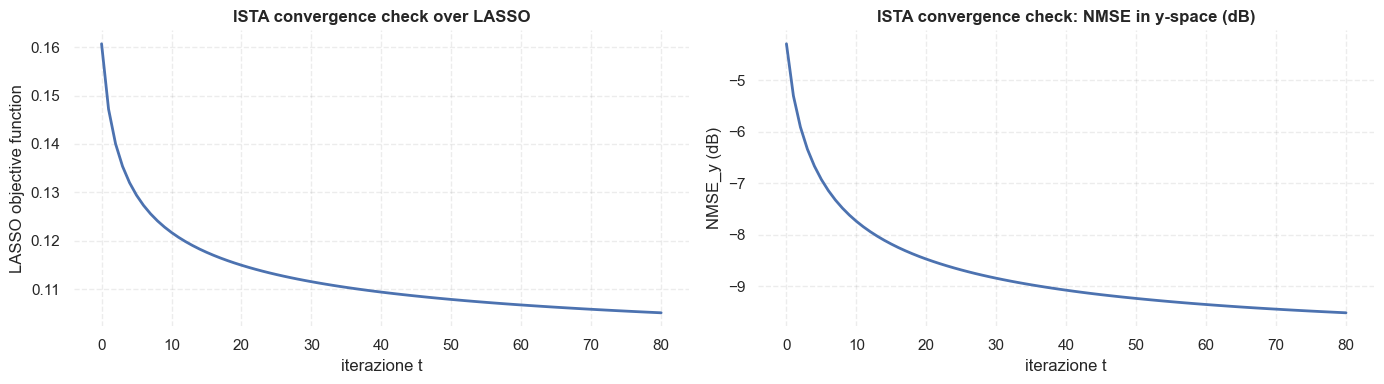

In [10]:
# ============================================================================
# Esperimento 2 - (2) Dizionario A e ISTA teacher (con check di convergenza)
# ============================================================================

# ---------- Parametri dizionario e ISTA teacher ----------
n_atoms_img = 256                                        # m = 256 atomi (sovra-completo: 256 > 64)
ista_cfg = ISTAConfig(lambda_lasso=0.12, ista_iters=80)  # lambda e n. iterazioni del teacher

# imparo A dalle patch con MiniBatchDictionaryLearning: su immagini reali e' piu' sensato di un dizionario casuale
from sklearn.decomposition import MiniBatchDictionaryLearning

dict_learner = MiniBatchDictionaryLearning(
    n_components=n_atoms_img,            # numero di atomi da imparare (= m)
    alpha=ista_cfg.lambda_lasso,         # forza della sparsita' nel dictionary learning
    max_iter=500,
    batch_size=1024,
    random_state=0,
    verbose=False,
)
dict_learner.fit(Y_train_img)            # imparo gli atomi sulle patch di training (centrate)

# traspongo e normalizzo le colonne
A_img_np = dict_learner.components_.T.astype(np.float32)
A_img_np /= (np.linalg.norm(A_img_np, axis=0, keepdims=True) + 1e-12)

A_img = jnp.asarray(A_img_np)

# ----------------------------------------------------------------------------
# Check della convergenza di ISTA 
# ----------------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

Y_conv = jnp.asarray(Y_train_img[:2048])

# sequenza completa x^0..x^{ista_iters} su questo sottoinsieme
x_seq_conv = ista_solve_all(
    Y_conv, A_img,
    lambda_lasso=ista_cfg.lambda_lasso,
    n_iters=ista_cfg.ista_iters,
    stability_factor=ista_cfg.stability_factor,
    eps=ista_cfg.eps,
    )

# (a) obiettivo LASSO lungo la sequenza
obj_seq = lasso_objective_seq_from_x_seq(
    x_seq_conv, Y_conv, A_img, lambda_lasso=ista_cfg.lambda_lasso,
    )

# (b) NMSE in y-space: ricostruisco y_hat^t = A x^t e misuro la distanza da y
y_hat_seq = x_seq_conv @ A_img.T                 # (T+1, N, n)
nmse_y_seq = nmse_db_seq(y_hat_seq, Y_conv)

obj_np = np.array(obj_seq)
nmse_y_np = np.array(nmse_y_seq)

# plot dei due check affiancati
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(np.arange(len(obj_np)), obj_np, linewidth=2)
axes[0].set_title("ISTA convergence check over LASSO", fontweight='bold')
axes[0].set_xlabel("iterazione t"); axes[0].set_ylabel("LASSO objective function")
axes[0].grid(True, linestyle='--', color='gray', alpha=0.15)

axes[1].plot(np.arange(len(nmse_y_np)), nmse_y_np, linewidth=2)
axes[1].set_title("ISTA convergence check: NMSE in y-space (dB)", fontweight='bold')
axes[1].set_xlabel("iterazione t"); axes[1].set_ylabel("NMSE_y (dB)")
axes[1].grid(True, linestyle='--', color='gray', alpha=0.15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------------
# Codici teacher: x_ISTA(Y) su tutte le patch (saranno i target di LISTA)
# ----------------------------------------------------------------------------
X_train_ista = ista_solve(
    jnp.asarray(Y_train_img), A_img,
    lambda_lasso=ista_cfg.lambda_lasso,
    n_iters=ista_cfg.ista_iters,
    stability_factor=ista_cfg.stability_factor,
    eps=ista_cfg.eps,
    )

X_test_ista = ista_solve(
    jnp.asarray(Y_test_img), A_img,
    lambda_lasso=ista_cfg.lambda_lasso,
    n_iters=ista_cfg.ista_iters,
    stability_factor=ista_cfg.stability_factor,
    eps=ista_cfg.eps,
    )

Epoch 01 | loss(batch)=0.000042 | MSE train=2.208e-05 test=2.145e-05 | NMSE train=-8.44 dB test=-8.27 dB
Epoch 05 | loss(batch)=0.000006 | MSE train=5.007e-06 test=5.180e-06 | NMSE train=-14.88 dB test=-14.44 dB
Epoch 10 | loss(batch)=0.000003 | MSE train=2.363e-06 test=2.632e-06 | NMSE train=-18.15 dB test=-17.38 dB
Epoch 15 | loss(batch)=0.000001 | MSE train=1.305e-06 test=1.553e-06 | NMSE train=-20.72 dB test=-19.67 dB
Epoch 20 | loss(batch)=0.000001 | MSE train=8.603e-07 test=1.067e-06 | NMSE train=-22.53 dB test=-21.30 dB
Epoch 25 | loss(batch)=0.000001 | MSE train=6.304e-07 test=8.136e-07 | NMSE train=-23.88 dB test=-22.48 dB


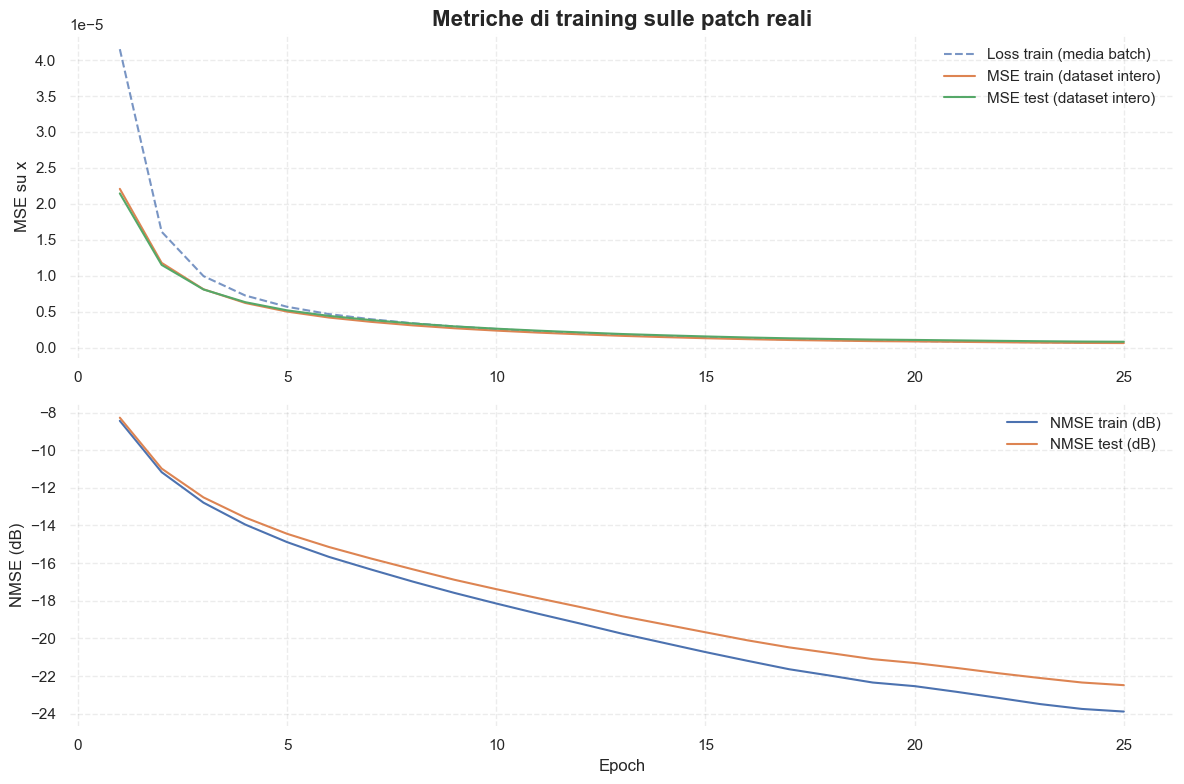

In [11]:
# ============================================================================
# Esperimento 2 - (3) Training di LISTA (student) sulle patch reali e plot
# ============================================================================
# Alleno LISTA a predire i codici x_ISTA (teacher) sulle patch reali

import optax
from flax.training import train_state


# ---------- Iperparametri (immagini) ----------
n_layers_img = 16
batch_size_img = 512
n_epochs_img = 25
lr_img = 3e-3     # learning rate 

# ---------- Modello e TrainState (stessa classe del sintetico, dizionario diverso) ----------
rng = jax.random.PRNGKey(0)

model_img = LISTAFlaxV2(
    A=A_img,                          # warm start sul dizionario delle immagini
    n_layers=n_layers_img,
    tied_weights=True,
    beta0=0.4,
    )

rng, rng_init = jax.random.split(rng)
params_img = model_img.init(rng_init, jnp.asarray(Y_train_img[:1]))   # init: prende le shape

state_img = train_state.TrainState.create(
    apply_fn=model_img.apply,
    params=params_img,
    # stesso gradient clipping degli altri training, per stabilita'
    tx=optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr_img)),
    )

# i target sono i codici del teacher
X_train_img_np = np.array(X_train_ista)
X_test_img_np = np.array(X_test_ista)

# ---------- Training --> riuso esattamente la stessa funzione del caso sintetico ----------
# cambia solo cosa e' X, qui sono i codici di ISTA invece del codice vero
state_img, hist_img = train_supervised_loop(
    state=state_img,
    Y_train_np=Y_train_img, X_train_np=X_train_img_np,
    Y_test_np=Y_test_img, X_test_np=X_test_img_np,
    batch_size=batch_size_img,
    n_epochs=n_epochs_img,
    seed=0,
    verbose_every=5,
    )


# ---------- Plot delle metriche di training ----------
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
epochs = np.arange(1, len(hist_img['train_loss']) + 1)
plt.figure(figsize=(12, 8))

# (1) MSE in x-space (errore sui codici)
plt.subplot(2, 1, 1)
plt.plot(epochs, hist_img['train_loss'], label='Loss train (media batch)', linestyle='--', alpha=0.75)
plt.plot(epochs, hist_img['train_mse'], label='MSE train (dataset intero)')
plt.plot(epochs, hist_img['test_mse'], label='MSE test (dataset intero)')
plt.title('Metriche di training sulle patch reali', fontsize=16, fontweight='bold')
plt.ylabel('MSE su x')
plt.grid(True, linestyle='--', color='gray', alpha=0.15)
plt.legend(framealpha=0)

# (2) NMSE in dB
plt.subplot(2, 1, 2)
plt.plot(epochs, hist_img['train_nmse_db'], label='NMSE train (dB)')
plt.plot(epochs, hist_img['test_nmse_db'], label='NMSE test (dB)')
plt.xlabel('Epoch')
plt.ylabel('NMSE (dB)')
plt.grid(True, linestyle='--', color='gray', alpha=0.15)
plt.legend(framealpha=0)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## <code style="background:purple;color:white">**Valutazione: sparsità, errore, timing**</code>

### <code style="background:royalblue;color:white">**Cosa misuro e come leggerlo**</code>
Confronto ISTA e LISTA su tre viste: una tabella di sparsità, la curva dell'errore in $y$, e una tabella dei tempi d'esecuzione.

$\leadsto$ ***1) Tabella di sparsità della rappresentazione (Originale vs ISTA vs LISTA):***

Metto a confronto la patch **originale** $y$ con i due codici sparsi $\hat x$ (ISTA e LISTA). Per ciascuno riporto:
- `nnz_medio`: numero medio di componenti attive (con $|\cdot|>\tau$, $\tau=10^{-3}$);
- `density`: frazione di componenti attive, $\text{nnz}/\text{dim}$;
- `l1_norm`: norma $\ell_1$ media;
- `NMSE_y (dB)`: errore finale di ricostruzione in $y$ (per la patch originale non si applica).

**La colonna `NMSE_y (dB)`** dà il valore **finale** di ISTA (80 iter) e LISTA (16 layer), cioè il punto di arrivo (estremo destro) della curva del punto 2: valori vicini significano stessa qualità di ricostruzione.

$\leadsto$ ***2) Errore di ricostruzione in $y$-space (NMSE $_y$ ) per profondità:*** 

Per ogni $t$ ricostruisco $\hat y^t = A\hat x^t$ e misuro
$$\mathrm{NMSE}_y(t)=10\log_{10}\!\left(\frac{\sum\|\hat y^t-y\|_2^2}{\sum\|y\|_2^2}\right)$$

<code style="background:darkred;color:white">**N.B.:**</code> 

La **`Non-monotonia`** della curva di LISTA avviene perché la loss supervisiona solo l'ultimo layer $x^L$, quindi i layer intermedi non sono vincolati a migliorare a ogni passo. Segno con un punto la profondità $t^\star$ che minimizza NMSE$_y$ (early stopping in profondità).

$\leadsto$ ***3) Tabella dei tempi di inference (post-JIT)*** 

Misuro il tempo del solo forward pass in inferenza **dopo** la compilazione JAX (warmup), su un batch di patch, per LISTA (16 layer) e ISTA (80 iter).

<code style="background:darkred;color:white">**N.B.:**</code> 
Il motivo percui non faccio il confronto a parità di iterazioni è che voglio vedere in quanto tempo le due soluzioni mi danno lo stesso risultato 

,nnz_medio,density,l1_norm,NMSE_y (dB)
"Originale (patch y, R^64)",63.1,0.985,4.224,NaN
"ISTA (segnale x, R^256)",19.6,0.076,0.619,-9.33
"LISTA (segnale x, R^256)",19.8,0.078,0.616,-9.23


- La patch originale usa quasi tutte le sue componenti (~1)
- I segnali ISTA/LISTA solouna piccola frazione (~0.08) --> rappresentazione sparsa.
- density, l1 e NMSE_y quasi identiche tra ISTA e LISTA -> LISTA replica bene il teacher.


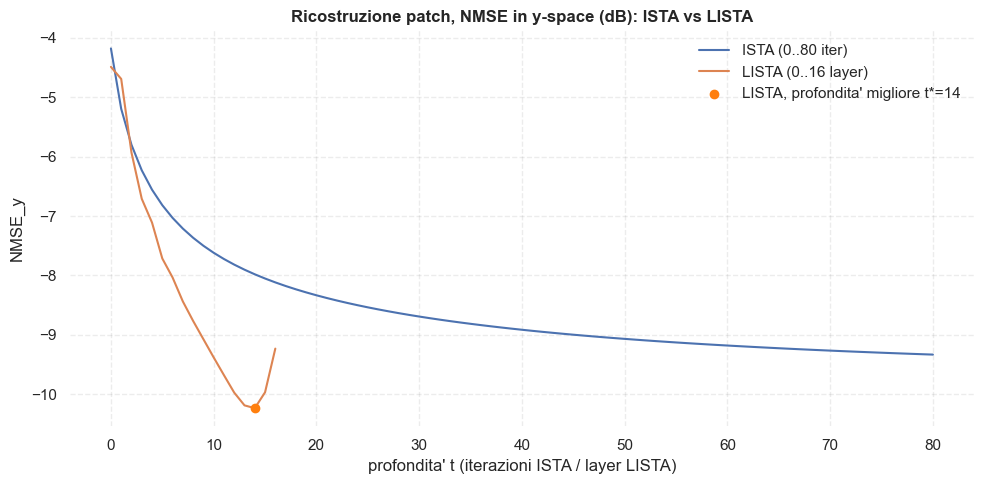

,tempo (ms),speedup
metodo,,
LISTA (16 layer),31.99,1.0
ISTA (80 iter),166.75,5.2


Batch di 5120 patch, tempi post-warmup (esclusa la compilazione).
LISTA-16 da' gli stessi codici di ISTA-80 in circa 5x meno tempo.


In [ ]:
# ============================================================================
# Valutazioni: sparsita' della rappresentazione, errore in y, timing
# ============================================================================

import time
from IPython.display import display
import pandas as pd

Y_te = jnp.asarray(Y_test_img)        # patch di test (le y osservate)

Xhat_lista_te = model_img.apply(state_img.params, Y_te)
Xhat_ista_te  = X_test_ista


# ----------------------------------------------------------------------------
# NMSE_y finale: errore di ricostruzione A x_hat vs patch osservata y (ISTA e LISTA)
# ----------------------------------------------------------------------------
# nmse_db_seq vuole un asse profondita' davanti, quindi passo y_hat[None,...] e prendo l'unico elemento
def _nmse_y_db_final(Xhat):
    y_hat = Xhat @ A_img.T                       # ricostruzione A x_hat
    return float(nmse_db_seq(y_hat[None, ...], Y_te)[0])

nmse_y_ista_final  = _nmse_y_db_final(Xhat_ista_te)
nmse_y_lista_final = _nmse_y_db_final(Xhat_lista_te)


# ----------------------------------------------------------------------------
# Tabella 1 - sparsita' della rappresentazione: Originale vs ISTA vs LISTA
# ----------------------------------------------------------------------------
def _sparsity_row(x, thr=1e-3):
    x = np.asarray(x)
    nnz = np.sum(np.abs(x) > thr, axis=1)             # componenti attive per campione
    return {
        'nnz_medio': float(np.mean(nnz)),             # n. medio di componenti attive
        'density': float(np.mean(nnz / x.shape[1])),  # = nnz / dimensione della rappresentazione
        'l1_norm': float(np.mean(np.sum(np.abs(x), axis=1))),
    }

rows = {
    f'Originale (patch y, R^{Y_te.shape[1]})':      {**_sparsity_row(Y_te),          'NMSE_y (dB)': np.nan},
    f'ISTA (segnale x, R^{Xhat_ista_te.shape[1]})':  {**_sparsity_row(Xhat_ista_te),  'NMSE_y (dB)': nmse_y_ista_final},
    f'LISTA (segnale x, R^{Xhat_lista_te.shape[1]})':{**_sparsity_row(Xhat_lista_te), 'NMSE_y (dB)': nmse_y_lista_final},
}
df_sparsity = pd.DataFrame(rows).T[['nnz_medio', 'density', 'l1_norm', 'NMSE_y (dB)']]
display(df_sparsity.round({'nnz_medio': 1, 'density': 3, 'l1_norm': 3, 'NMSE_y (dB)': 2}))
print("- La patch originale usa quasi tutte le sue componenti (~1)")
print("- I segnali ISTA/LISTA solouna piccola frazione --> rappresentazione sparsa.")
print("- density, l1 e NMSE_y quasi identiche tra ISTA e LISTA -> LISTA replica bene il teacher.")


# ----------------------------------------------------------------------------
# NMSE_y per profondita': LISTA (per layer) vs ISTA (per iterazione)
# ----------------------------------------------------------------------------
@jax.jit
def lista_y_nmse_per_layer_db(params, Y):
    _, x_seq = model_img.apply(params, Y, method=LISTAFlaxV2.forward_all)  # (L+1, N, m)
    return nmse_db_seq(x_seq @ A_img.T, Y)                                  # (L+1,)

nmse_y_lista = np.array(lista_y_nmse_per_layer_db(state_img.params, Y_te))

x_seq_ista = ista_solve_all(
    Y_te, A_img,
    lambda_lasso=ista_cfg.lambda_lasso, n_iters=ista_cfg.ista_iters,
    stability_factor=ista_cfg.stability_factor, eps=ista_cfg.eps,
    )
nmse_y_ista = np.array(nmse_db_seq(x_seq_ista @ A_img.T, Y_te))

# profondita' di LISTA che minimizza NMSE_y (early stopping in profondita')
t_best_y = int(np.argmin(nmse_y_lista))

plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(nmse_y_ista)), nmse_y_ista, label=f'ISTA (0..{ista_cfg.ista_iters} iter)')
plt.plot(np.arange(len(nmse_y_lista)), nmse_y_lista, label=f'LISTA (0..{n_layers_img} layer)')
plt.scatter([t_best_y], [nmse_y_lista[t_best_y]], color='tab:orange', zorder=3,
            label=f"LISTA, profondita' migliore t*={t_best_y}")
plt.title('Ricostruzione patch, NMSE in y-space (dB): ISTA vs LISTA', fontweight='bold')
plt.xlabel("profondita' t (iterazioni ISTA / layer LISTA)")
plt.ylabel("NMSE_y")
plt.grid(True, linestyle='--', color='gray', alpha=0.15)
plt.legend(framealpha=0)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------------
# Tabella 2 - tempo di inference post-JIT: LISTA-16 vs ISTA-80
# ----------------------------------------------------------------------------
# misuro la sola forward (stima dei codici) dopo il warmup di compilazione
@jax.jit
def _lista_codes(Y):
    return model_img.apply(state_img.params, Y)

def _ista_codes(Y):
    return ista_solve(Y, A_img, lambda_lasso=ista_cfg.lambda_lasso, n_iters=ista_cfg.ista_iters,
                      stability_factor=ista_cfg.stability_factor, eps=ista_cfg.eps)

Y_bench = Y_te
_ = _lista_codes(Y_bench).block_until_ready()   # warmup: la prima chiamata compila
_ = _ista_codes(Y_bench).block_until_ready()

# prendo il minimo su piu' ripetizioni, cosi' il tempo e' meno rumoroso
def _time_ms(fn, reps=5):
    best = np.inf
    for _ in range(reps):
        t0 = time.perf_counter(); fn().block_until_ready()
        best = min(best, (time.perf_counter() - t0) * 1e3)
    return best

ms_lista = _time_ms(lambda: _lista_codes(Y_bench))
ms_ista  = _time_ms(lambda: _ista_codes(Y_bench))

df_timing = pd.DataFrame([
    {'metodo': f'LISTA ({n_layers_img} layer)', 'tempo (ms)': round(ms_lista, 2), 'speedup': 1.0},
    {'metodo': f'ISTA ({ista_cfg.ista_iters} iter)',  'tempo (ms)': round(ms_ista, 2),  'speedup': round(ms_ista / ms_lista, 1)},
]).set_index('metodo')
display(df_timing)
print(f"Batch di {int(Y_bench.shape[0])} patch, tempi post-warmup (esclusa la compilazione).")
print(f"LISTA-{n_layers_img} da' gli stessi codici di ISTA-{ista_cfg.ista_iters} in circa {ms_ista/ms_lista:.0f}x meno tempo.")

Esempio 1:
  ISTA  | patch-MSE=7.287e-04 | patch-NMSE=-25.58 dB | PSNR=31.37 dB
  LISTA | patch-MSE=7.688e-04 | patch-NMSE=-25.35 dB | PSNR=31.14 dB


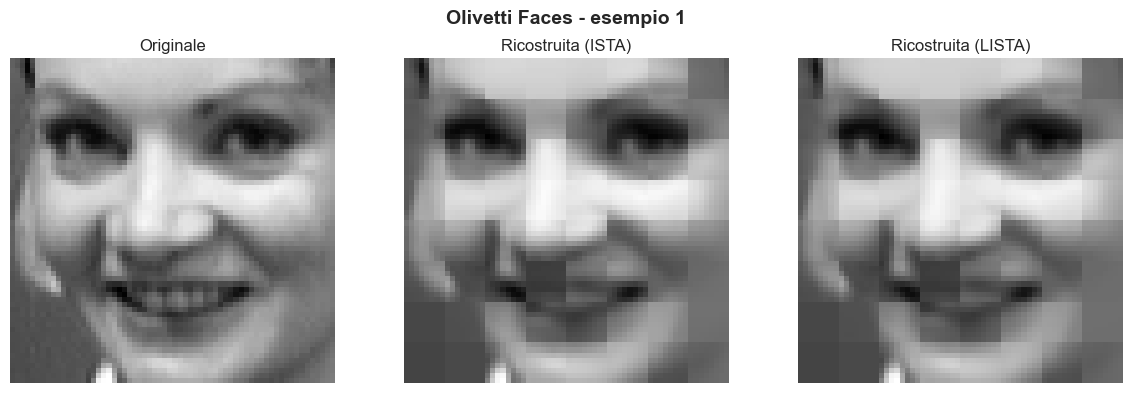

Esempio 2:
  ISTA  | patch-MSE=9.389e-04 | patch-NMSE=-26.13 dB | PSNR=30.27 dB
  LISTA | patch-MSE=9.393e-04 | patch-NMSE=-26.13 dB | PSNR=30.27 dB


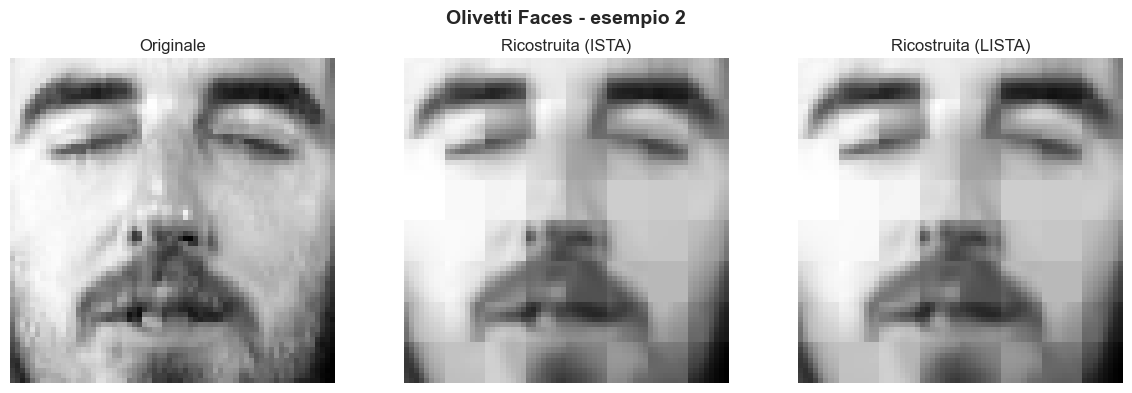

Esempio 3:
  ISTA  | patch-MSE=8.176e-04 | patch-NMSE=-24.07 dB | PSNR=30.87 dB
  LISTA | patch-MSE=8.394e-04 | patch-NMSE=-23.96 dB | PSNR=30.76 dB


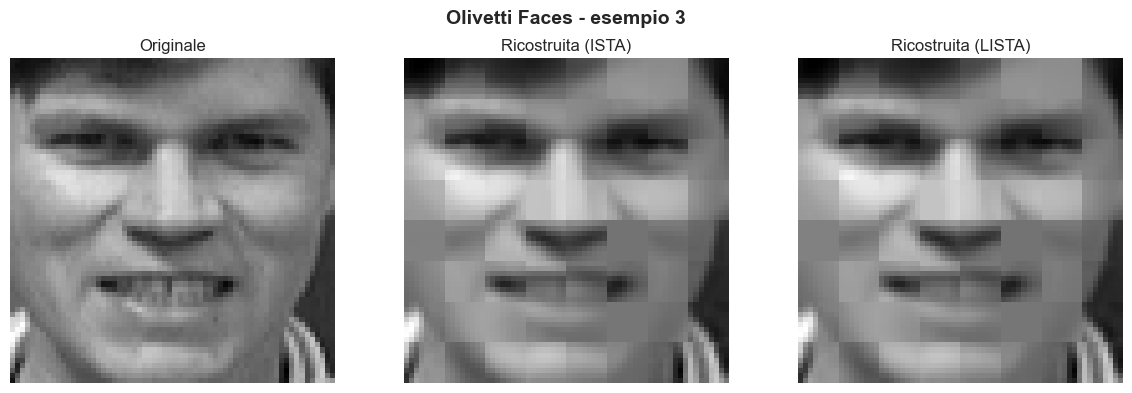

In [ ]:
# ============================================================================
# Ricostruzione immagine e metriche: Originale vs ISTA vs LISTA
# ============================================================================
# Verifico, qualitativamente e quantitativamente, che LISTA (pochi layer) approssima ISTA
# (molte iterazioni) nella ricostruzione patch-wise
# Non stampo x (e' un vettore di coefficienti) ma stampo y_hat = A x_hat ricomposto in immagine


def _psnr_from_mse(mse: float, data_range: float = 1.0, eps: float = 1e-12) -> float:
    """PSNR(dB) da MSE e range del segnale (immagini in [0,1] => range=1)"""
    mse = float(mse)
    return 20.0 * np.log10(data_range) - 10.0 * np.log10(mse + eps)


def _patch_metrics(y_true: np.ndarray, y_hat: np.ndarray, eps: float = 1e-12):
    """Metriche in spazio patch (y): MSE, NMSE(dB) (piu' negativa = meglio), PSNR(dB) (piu' alto = meglio)"""
    err = y_hat - y_true
    mse = float(np.mean(err**2))
    nmse = float(np.sum(err**2) / (np.sum(y_true**2) + eps))
    nmse_db = 10.0 * np.log10(nmse + eps)
    psnr = _psnr_from_mse(mse, data_range=1.0, eps=eps)
    return mse, nmse_db, psnr


def reconstruct_image_patchwise(
    image: np.ndarray,
    *,
    A: jnp.ndarray,
    patch_size: int,
    code_fn,                # funzione y_centered -> x_hat (sara' LISTA oppure ISTA)
    clip: bool = True,
    ):
    """
    Ricostruzione patch-wise (non-overlapping) di una immagine
    
    Pipeline:
      1) estraggo patch non-overlapping;
      2) centro ogni patch (sottraggo la media) - come in training;
      3) stimo i codici x_hat = code_fn(y_centered);
      4) ricostruisco y_hat_centered = A x_hat;
      5) ri-aggiungo la media di ciascuna patch;
      6) ricompongo l'immagine dalle patch.
    Ritorna (img_hat, patch vere non centrate, patch ricostruite non centrate)
    """
    H, W = image.shape

    patches = _extract_patches_non_overlapping(image[None, ...], patch_size=patch_size)

    patch_means = patches.mean(axis=1, keepdims=True)   # media di ogni patch (la componente DC)
    patches_centered = patches - patch_means            # patch centrate, stesso preprocessing del training

    Y_centered = jnp.asarray(patches_centered)
    X_hat = code_fn(Y_centered)                          # codici stimati (LISTA o ISTA)

    Y_hat = np.array(X_hat @ A.T) + patch_means          # y_hat = A x_hat, poi ri-aggiungo la media

    if clip:
        Y_hat = np.clip(Y_hat, 0.0, 1.0)                 # riporto nei valori validi di un'immagine [0,1]

    img_hat = _reconstruct_from_patches_non_overlapping(
        Y_hat, n_images=1, H=H, W=W, patch_size=patch_size,
        )[0]

    if clip:
        img_hat = np.clip(img_hat, 0.0, 1.0)

    return img_hat, patches, Y_hat


# due solver con la stessa interfaccia code_fn(Y_centered) -> X_hat
code_fn_lista = lambda Y_centered: model_img.apply(state_img.params, Y_centered)
code_fn_ista = lambda Y_centered: ista_solve(
    Y_centered, A_img,
    lambda_lasso=ista_cfg.lambda_lasso, n_iters=ista_cfg.ista_iters,
    stability_factor=ista_cfg.stability_factor, eps=ista_cfg.eps,
    )


# confronto su 3 immagini del test set
n_show = 3
for i in range(n_show):
    img = np.clip(images_test[i], 0.0, 1.0)

    # ricostruzione con ISTA (teacher) e con LISTA (student)
    img_hat_ista, y_true, y_hat_ista = reconstruct_image_patchwise(
        img, A=A_img, patch_size=patch_size, code_fn=code_fn_ista, clip=True)
    img_hat_lista, _, y_hat_lista = reconstruct_image_patchwise(
        img, A=A_img, patch_size=patch_size, code_fn=code_fn_lista, clip=True)

    # metriche in y (non in x): quanto bene A x_hat approssima le patch osservate
    mse_ista, nmse_db_ista, psnr_ista = _patch_metrics(y_true, y_hat_ista)
    mse_lista, nmse_db_lista, psnr_lista = _patch_metrics(y_true, y_hat_lista)

    print(f"Esempio {i+1}:")
    print(f"  ISTA  | patch-MSE={mse_ista:.3e} | patch-NMSE={nmse_db_ista:.2f} dB | PSNR={psnr_ista:.2f} dB")
    print(f"  LISTA | patch-MSE={mse_lista:.3e} | patch-NMSE={nmse_db_lista:.2f} dB | PSNR={psnr_lista:.2f} dB")

    # tre pannelli: originale vs ISTA vs LISTA
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Olivetti Faces - esempio {i+1}", fontsize=14, fontweight='bold')
    plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Originale'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(img_hat_ista, cmap='gray'); plt.title('Ricostruita (ISTA)'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(img_hat_lista, cmap='gray'); plt.title('Ricostruita (LISTA)'); plt.axis('off')
    plt.tight_layout()
    plt.show()

### <code style="background:green;color:white">**Interpretazione dei risultati**</code>

Nel caso teacher/student il risultato e' quello atteso: LISTA **riproduce** ISTA e non lo batte, perche' il target sono proprio i codici di ISTA. Lo confermano tre osservazioni:
- le **statistiche di sparsita'** (density ~ 0.076 vs 0.078, circa 20 coefficienti attivi) sono quasi identiche tra i due;
- la curva **NMSE in y-space** mostra che LISTA in ~16 layer raggiunge lo stesso errore di ricostruzione di ISTA-80;
- le **ricostruzioni** e le metriche PSNR (~31 dB) sono indistinguibili, visivamente e numericamente.

Il vantaggio pratico è nel **timing**: LISTA ottiene questi segnali in una sola forward pass, circa 5x piu' veloce di ISTA-80. E' la dimostrazione dell'inferenza ammortizzata su dati reali.

## <code style="background:purple;color:white">**Esperimento 3 — Denoising di immagini**</code>

In questo esperimento passo dalla ricostruzione sparse coding al **denoising patch-wise**. L'input non è più una patch pulita, ma una patch rumorosa
$$
\tilde y = y + \varepsilon
$$
e l'obiettivo non è imitare i codici prodotti da ISTA, bensì ricostruire direttamente la **patch pulita** $y$.

Per patch $16\times16$, ogni osservazione ha dimensione $n=256$. Uso un dizionario fisso e sovracompleto:
$$ A = (H_{256}\mid I_{256}) \in \mathbb{R}^{256\times512} $$

Qui $H_{256}$ è la base **2D-DCT**, adatta a rappresentare la struttura regolare delle immagini tramite pochi coefficienti cosinusoidali. $I_{256}$ è la matrice identità, utile per modellare residui e rumore locali pixel-per-pixel.

La funzione $\Phi_\Theta$ di LISTA riceve la patch rumorosa centrata $\tilde y$, produce un codice sparso $\hat x$, e ricostruisce:

$$ \hat y = A\hat x$$

La loss è nello spazio immagine, non nello spazio dei codici:

$$\min_\Theta \mathbb{E}\left[\|y - A\Phi_\Theta(\tilde y)\|_2^2\right]$$

Rispetto all'esperimento precedente dove LISTA imparava a riprodurre ISTA (e quindi poteva al più eguagliarlo), qui invece il target è il segnale pulito, quindi LISTA può imparare una funzione di denoising migliore della baseline ISTA.

Dizionario denoising A = (H | I): (256, 512) (n=256, m=512)
Epoch 01 | loss denoising (y-space) = 2.037281e-03
Epoch 05 | loss denoising (y-space) = 1.266358e-03
Epoch 10 | loss denoising (y-space) = 1.034111e-03
Epoch 15 | loss denoising (y-space) = 9.196898e-04
Epoch 20 | loss denoising (y-space) = 8.444154e-04
Epoch 25 | loss denoising (y-space) = 7.901265e-04
Epoch 30 | loss denoising (y-space) = 7.516731e-04


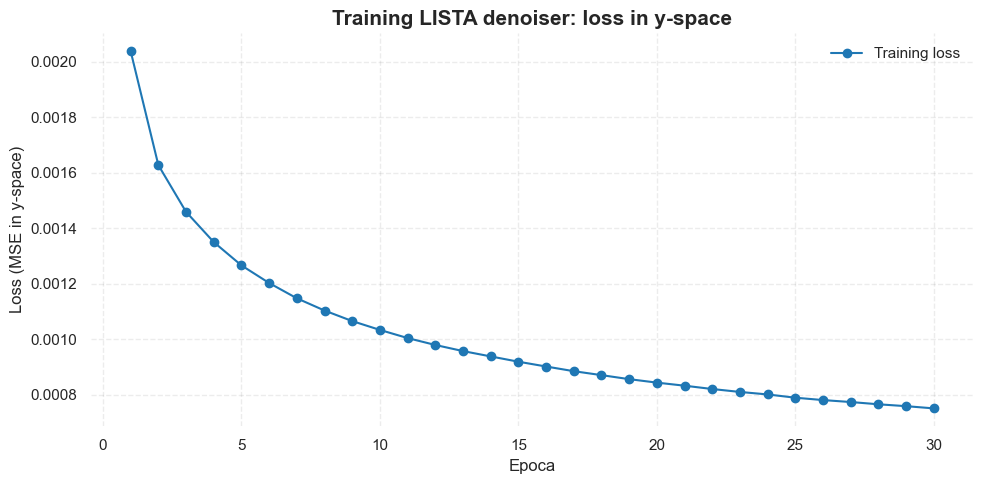

In [14]:
# ============================================================================
# Esperimento 3 - (1) Denoising: dizionario A=(H|I), patch rumorose, training LISTA
# ============================================================================

from scipy.fftpack import dct   # DCT (Discrete Cosine Transform): la uso per costruire la base 2D-DCT

# ---------- Iperparametri denoising ----------
patch_size_dn = 16          # 16x16, quindi n = 256
n_dn          = patch_size_dn ** 2
train_snr_db  = 20.0        # un solo livello di rumore su cui alleno (poi testo su un range di SNR)
n_layers_dn   = 16          # profondita' di LISTA (coerente col resto del notebook)
n_epochs_dn   = 30
lr_dn         = 3e-3
beta0_dn      = 0.15        # soglia iniziale (gioca il ruolo di lambda per il denoising)

# ---------- Dizionario A = (H | I), colonne normalizzate ----------
# - H = base 2D-DCT ortonormale (n x n): la costruisco come kron della DCT-1D con se stessa, e cattura la struttura della patch. 
# - I = identita' (n x n): serve a spiegare residui/rumore impulsivo pixel-wise
D1     = dct(np.eye(patch_size_dn), norm='ortho', axis=0)        # DCT-1D (p x p)
H_dct  = np.kron(D1, D1).astype(np.float32)                       # 2D-DCT (n x n)
A_dn_np = np.concatenate([H_dct, np.eye(n_dn, dtype=np.float32)], axis=1)  # (n, 2n)
A_dn_np /= (np.linalg.norm(A_dn_np, axis=0, keepdims=True) + 1e-12)        # atomi a norma 1
A_dn = jnp.asarray(A_dn_np)
print("Dizionario denoising A = (H | I):", A_dn_np.shape, f"(n={n_dn}, m={2*n_dn})")

# ---------- Patch 16x16 dalle stesse immagini Olivetti (split gia' fatto) ----------
clean_tr = _extract_patches_non_overlapping(images_train, patch_size_dn).astype(np.float32)
clean_te = _extract_patches_non_overlapping(images_test,  patch_size_dn).astype(np.float32)

# ---------- Rumore calibrato su un SNR (dB): var_noise = Power_signal / 10^(SNR/10) ----------
def _sigma_for_snr(clean: np.ndarray, snr_db: float) -> float:
    p_sig = float(np.mean(clean ** 2))
    return float(np.sqrt(p_sig / (10.0 ** (snr_db / 10.0))))

def _add_noise_np(clean: np.ndarray, sigma: float, seed: int) -> np.ndarray:
    g = np.random.default_rng(seed)
    return (clean + sigma * g.standard_normal(clean.shape)).astype(np.float32)

sigma_tr = _sigma_for_snr(clean_tr, train_snr_db)
noisy_tr = _add_noise_np(clean_tr, sigma_tr, seed=0)

# ---------- Centro per la media della patch rumorosa -----------------------------------------
m_tr    = noisy_tr.mean(axis=1, keepdims=True)
Yin_tr  = (noisy_tr - m_tr).astype(np.float32)   
Ytgt_tr = (clean_tr - m_tr).astype(np.float32)  

# ---------- LISTA denoiser: stessa classe, warm-start su A=(H|I) ----------
model_dn  = LISTAFlaxV2(A=A_dn, n_layers=n_layers_dn, tied_weights=True, beta0=beta0_dn)
params_dn = model_dn.init(jax.random.PRNGKey(0), jnp.asarray(Yin_tr[:1]))
state_dn  = train_state.TrainState.create(
    apply_fn=model_dn.apply, params=params_dn,
    tx=optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr_dn)),
    )

# ---------- Training step con loss di denoising in y-space ----------
# adesso la loss non e' sui codici x, ma sulla ricostruzione A x_hat confrontata con la patch pulita 
# quindi devo scrivere una funzione di loss e train_step apposita
@jax.jit
def denoise_train_step(state, y_in, y_tgt):
    def loss_fn(params):
        x_hat = state.apply_fn(params, y_in)     # codice sparso dalla patch rumorosa
        y_rec = x_hat @ A_dn.T                    # ricostruzione A x_hat (in y-space)
        return jnp.mean((y_rec - y_tgt) ** 2)     # MSE verso la patch pulita
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    return state.apply_gradients(grads=grads), loss

# ---------- Loop di training (mini-batch, drop_last) ----------
Yin_j, Ytgt_j = jnp.asarray(Yin_tr), jnp.asarray(Ytgt_tr)
N_dn, bs_dn = Yin_tr.shape[0], 512
rng_dn = np.random.default_rng(0)
train_losses_dn = []
for epoch in range(1, n_epochs_dn + 1):
    idx = rng_dn.permutation(N_dn)[:(N_dn // bs_dn) * bs_dn]
    running, nb = 0.0, 0
    for i in range(0, len(idx), bs_dn):
        b = idx[i:i + bs_dn]
        state_dn, loss = denoise_train_step(state_dn, Yin_j[b], Ytgt_j[b])
        running += float(loss); nb += 1
    epoch_loss = running / max(nb, 1)
    train_losses_dn.append(epoch_loss)
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | loss denoising (y-space) = {epoch_loss:.6e}")

# ---------- Plot della convergenza della loss ----------
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs_dn + 1), train_losses_dn, 'o-', color='tab:blue', label='Training loss')
plt.title('Training LISTA denoiser: loss in y-space', fontsize=15, fontweight='bold')
plt.xlabel('Epoca')
plt.ylabel('Loss (MSE in y-space)')
plt.grid(True, linestyle='--', color='gray', alpha=0.15)
plt.legend(framealpha=0)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### <code style="background:royalblue;color:white">**Verifica della robustezza del denoiser al variare del livello di rumore**</code>

Una volta addestrato il denoiser LISTA a un livello di rumore specifico (SNR $=20$ dB), lo testo sulle patch del test set su un range di livelli di rumore (SNR da 14 a 30 dB) per verificare la **robustezza** del modello. L'obiettivo è vedere se LISTA mantiene prestazioni superiori rispetto a ISTA anche quando il livello di rumore cambia rispetto a quello di training. Come metrica di valutazione uso il **PSNR** (Peak Signal-to-Noise Ratio) tra la patch pulita $y$ e la patch ricostruita $\hat y = A\hat x$.

Per il confronto passo le patch di test anche a ISTA-80 il quale però mantiene il parametro di regolarizzazione $\lambda$ fissato a quello ottimale per SNR $=20$ dB (il livello di rumore di training).

ISTA denoiser: lambda* (tarato @ SNR=20 dB) = 0.08
SNR_in=14 dB | noisy=18.82 | ISTA-80=22.20 | LISTA-16=23.02 dB
SNR_in=16 dB | noisy=20.85 | ISTA-80=24.55 | LISTA-16=25.60 dB
SNR_in=18 dB | noisy=22.84 | ISTA-80=26.50 | LISTA-16=27.69 dB
SNR_in=20 dB | noisy=24.83 | ISTA-80=27.84 | LISTA-16=29.15 dB
SNR_in=22 dB | noisy=26.85 | ISTA-80=28.61 | LISTA-16=30.08 dB
SNR_in=24 dB | noisy=28.84 | ISTA-80=28.92 | LISTA-16=30.59 dB
SNR_in=26 dB | noisy=30.83 | ISTA-80=29.02 | LISTA-16=30.90 dB
SNR_in=28 dB | noisy=32.83 | ISTA-80=29.08 | LISTA-16=31.08 dB
SNR_in=30 dB | noisy=34.83 | ISTA-80=29.10 | LISTA-16=31.19 dB


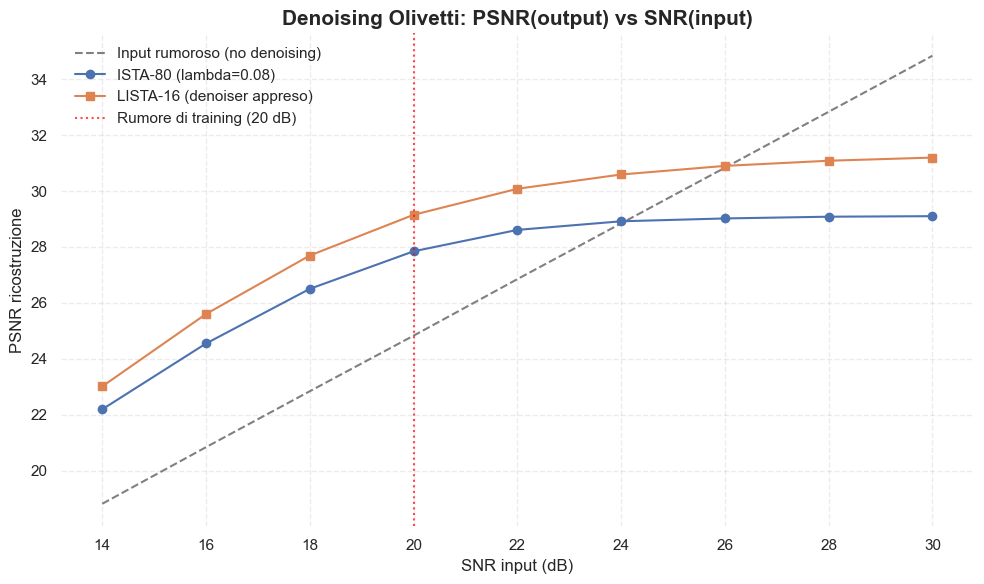

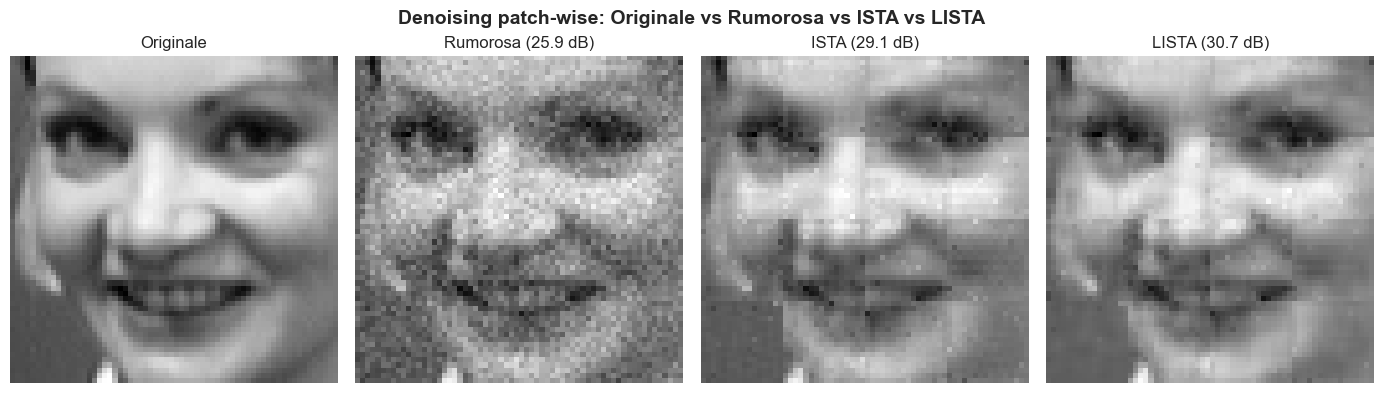

In [ ]:
# ============================================================================
# Esperimento 3 - (2) Baseline ISTA, curva PSNR vs SNR, confronto visivo
# ============================================================================

def _psnr(clean, hat):
    """PSNR(dB) per immagini/patch in [0,1] (range=1 => 20log10(1)=0)."""
    mse = float(np.mean((np.asarray(clean) - np.asarray(hat)) ** 2))
    return -10.0 * np.log10(mse + 1e-12)

# ---------- Baseline ISTA denoiser: lambda scelto al livello di rumore di training ----------
# trovo il valore di lambda che massimizza il PSNR sulle patch rumorose di training per lo stesso livello di rumore (SNR=20 dB) su cui ho addestrato LISTA
best = None
for lam in [0.03, 0.05, 0.08, 0.12, 0.18, 0.25]:
    y_hat = np.array(ista_solve(jnp.asarray(Yin_tr), A_dn,
                                lambda_lasso=lam, n_iters=ista_cfg.ista_iters) @ A_dn.T) + m_tr
    pp = _psnr(clean_tr, y_hat)
    if best is None or pp > best[1]:
        best = (lam, pp)
lam_dn = best[0]
print(f"ISTA denoiser: lambda* (tarato @ SNR={train_snr_db:.0f} dB) = {lam_dn}")

# ---------- Test: PSNR(output) vs SNR(input) sulle patch di test ----------
snr_grid = [14, 16, 18, 20, 22, 24, 26, 28, 30]
psnr_noisy, psnr_ista, psnr_lista = [], [], []
for s in snr_grid:
    noisy_te = _add_noise_np(clean_te, _sigma_for_snr(clean_te, s), seed=100 + s)
    m_te   = noisy_te.mean(axis=1, keepdims=True)
    Yin_te = (noisy_te - m_te).astype(np.float32)
    y_i = np.array(ista_solve(jnp.asarray(Yin_te), A_dn,
                              lambda_lasso=lam_dn, n_iters=ista_cfg.ista_iters) @ A_dn.T) + m_te
    y_l = np.array(model_dn.apply(state_dn.params, jnp.asarray(Yin_te)) @ A_dn.T) + m_te
    psnr_noisy.append(_psnr(clean_te, noisy_te))
    psnr_ista.append(_psnr(clean_te, y_i))
    psnr_lista.append(_psnr(clean_te, y_l))
    print(f"SNR_in={s:2d} dB | noisy={psnr_noisy[-1]:5.2f} | ISTA-{ista_cfg.ista_iters}={psnr_ista[-1]:5.2f} | "
          f"LISTA-{n_layers_dn}={psnr_lista[-1]:5.2f} dB")

# ---------- Plot PSNR vs SNR ----------
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.plot(snr_grid, psnr_noisy, '--', color='gray', label='Input rumoroso (no denoising)')
plt.plot(snr_grid, psnr_ista,  'o-', label=f'ISTA-{ista_cfg.ista_iters} (lambda={lam_dn})')
plt.plot(snr_grid, psnr_lista, 's-', label=f'LISTA-{n_layers_dn} (denoiser appreso)')
plt.axvline(train_snr_db, color='red', linestyle=':', alpha=0.7,
            label=f'Rumore di training ({train_snr_db:.0f} dB)')
plt.title('Denoising Olivetti: PSNR(output) vs SNR(input)', fontsize=15, fontweight='bold')
plt.xlabel('SNR input (dB)'); plt.ylabel("PSNR ricostruzione")
plt.grid(True, linestyle='--', color='gray', alpha=0.15)
plt.legend(framealpha=0); sns.despine(left=True, bottom=True); plt.tight_layout(); plt.show()

# ---------- Confronto visivo su un'immagine intera di test (al rumore di training) ----------
img0 = np.clip(images_test[0], 0.0, 1.0)
pt   = _extract_patches_non_overlapping(img0[None, ...], patch_size_dn).astype(np.float32)
pt_noisy = _add_noise_np(pt, _sigma_for_snr(pt, train_snr_db), seed=7)
m0   = pt_noisy.mean(axis=1, keepdims=True)
yin0 = (pt_noisy - m0).astype(np.float32)
rec_i = np.clip(np.array(ista_solve(jnp.asarray(yin0), A_dn,
                                    lambda_lasso=lam_dn, n_iters=ista_cfg.ista_iters) @ A_dn.T) + m0, 0, 1)
rec_l = np.clip(np.array(model_dn.apply(state_dn.params, jnp.asarray(yin0)) @ A_dn.T) + m0, 0, 1)
to_img = lambda P: _reconstruct_from_patches_non_overlapping(P, 1, 64, 64, patch_size_dn)[0]
noisy_img = to_img(np.clip(pt_noisy, 0, 1))
panels = [img0, noisy_img, to_img(rec_i), to_img(rec_l)]
titles = ['Originale',
          f'Rumorosa ({_psnr(img0, noisy_img):.1f} dB)',
          f'ISTA ({_psnr(img0, to_img(rec_i)):.1f} dB)',
          f'LISTA ({_psnr(img0, to_img(rec_l)):.1f} dB)']
plt.figure(figsize=(14, 4))
plt.suptitle('Denoising patch-wise: Originale vs Rumorosa vs ISTA vs LISTA', fontsize=14, fontweight='bold')
for k, (im, t) in enumerate(zip(panels, titles)):
    plt.subplot(1, 4, k + 1); plt.imshow(im, cmap='gray'); plt.title(t); plt.axis('off')
plt.tight_layout(); plt.show()

# quello che mi aspetto: la curva LISTA sta sopra quella di ISTA a ogni SNR, ed entrambe sopra
# l'input rumoroso finche' il rumore e' significativo. 

### <code style="background:green;color:white">**Interpretazione dell'Esperimento 3**</code>

La curva PSNR-SNR conferma il comportamento atteso del denoiser appreso. In tutto il range considerato, LISTA-16 ottiene un PSNR più alto di ISTA-80. 

<code style="background:darkred;color:white">**N.B.:**</code>
La sgranatura a blocchi è dovuta principalmente alla ricostruzione **patch-wise non-overlapping**.

## <code style="background:purple;color:white">**Varianti convesse di LISTA**</code>

Il teorema di accoppiamento è il punto di partenza di una famiglia di varianti che **riducono i parametri imponendo la struttura** invece di impararla interamente, restando tutte nel regime convesso (penalità $\ell_1$).

### <code style="background:royalblue;color:white">**LISTA-CP (Coupled) e LISTA-CPSS**</code>
Impone direttamente l'accoppiamento del teorema ($W_2=I-W_1A$): resta **una sola** matrice per layer e l'update assume la forma "a residuo"
$$x^{t+1}=\mathcal S_{\beta^t}\big(x^t+(W^t)^\top(y-Ax^t)\big).$$
Meno parametri e convergenza più stabile. **CPSS** aggiunge il *support selection*: i coefficienti già grandi (support confermato) non vengono ri-sogliati, il che accelera la convergenza.

### <code style="background:royalblue;color:white">**TiLISTA (Tied)**</code>
Va oltre: **una sola** matrice $W$ condivisa da tutti i layer, modulata da uno **scalare per layer** $\gamma^t$:
$$x^{t+1}=\mathcal S_{\beta^t}\big(x^t+\gamma^t\,W^\top(y-Ax^t)\big).$$
Parametri appresi: $W$ e $\{\gamma^t,\beta^t\}$, quindi pochissimi.

### <code style="background:royalblue;color:white">**ALISTA (Analytic)**</code>
Non impara affatto $W$: la **precalcola analiticamente** minimizzando la coerenza con $A$,
$$\bar W=\arg\min_W\|W^\top A\|_F^2\quad\text{s.t.}\quad (W^\top A)_{jj}=1,$$
e impara **solo** i $2L$ scalari $\{\gamma^t,\beta^t\}$. Massime prestazioni con il minimo di parametri appresi.